# HEPSIM Evaluation: Pythia 8 Quark/Gluon Jet Analysis
**GSoC 2026 · ML4SCI: HEP Simulation**

---

## Summary

This notebook analyses the Pythia 8 Quark and Gluon Jets dataset (Zenodo record 3164691), loading up to five standard `QG_jets_*.npz` files (~500 k jets, balanced 50/50 quark/gluon). **Part (a)** explores the data: real constituents are identified with a `pT > 0` mask to handle zero-padding, and we visualise multiplicity and leading-constituent kinematics — gluon jets are broader and more populous, consistent with the larger QCD colour factor $C_A = 3$ vs $C_F = 4/3$. **Part (b)** computes three jet observables — invariant mass, angular width $w$, and $p_T$ dispersion $p_T^D$ — vectorised over the full dataset; all three show clear quark/gluon separation. **Part (c)** implements a Lorentz boost to each jet's rest frame via $\vec{\beta} = \vec{p}_J / E_J$, verified to reduce the total three-momentum to floating-point noise ($< 10^{-8}$ GeV), and visualises constituent distributions in the $(p_x, p_y)$ and $(\theta, \phi)$ planes — quark jets appear more collimated while gluon jets spread isotropically. **Part (d)** trains four classifiers (Logistic Regression, Random Forest, Gradient BDT, PyTorch MLP) on 13 combined lab- and rest-frame features; eight ablation studies characterise feature importance, frame choice, model complexity, and data efficiency. Constituent multiplicity and jet width are the dominant discriminants; CM-frame event-shape variables (sphericity, $C$-parameter) add a complementary ~0.3–0.8% AUC gain over lab-frame features alone.

In [ ]:
# ─────────────────────────────────────────────
# Standard library
# ─────────────────────────────────────────────
import os
import glob
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────
# Numerical / Scientific
# ─────────────────────────────────────────────
import numpy as np

# ─────────────────────────────────────────────
# Visualisation
# ─────────────────────────────────────────────
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LogNorm
import matplotlib.patches as mpatches
%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
QUARK_COLOR  = '#E63946'   # red
GLUON_COLOR  = '#457B9D'   # blue

# ─────────────────────────────────────────────
# Machine Learning
# ─────────────────────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing    import StandardScaler
from sklearn.linear_model     import LogisticRegression
from sklearn.ensemble         import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics          import (roc_curve, roc_auc_score,
                                       confusion_matrix, ConfusionMatrixDisplay,
                                       classification_report)
from sklearn.inspection       import permutation_importance
from sklearn.pipeline         import Pipeline

# ─────────────────────────────────────────────
# PyTorch
# ─────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# ─────────────────────────────────────────────
# Reproducibility
# ─────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# ─────────────────────────────────────────────
# Data path – UPDATE THIS to your folder
# ─────────────────────────────────────────────
DATA_DIR = './jets_data'   # folder containing QG_jets_*.npz (no withbc)

print('NumPy   :', np.__version__)
print('PyTorch :', torch.__version__)
print('CUDA    :', torch.cuda.is_available())
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device  :', DEVICE)

NumPy   : 2.0.2
PyTorch : 2.10.0+cu128
CUDA    : True
Device  : cuda


---
## Part (a) – Data Loading & Exploration

We load up to five standard `QG_jets_*.npz` files from the Zenodo dataset (excluding `withbc` variants). Each file provides a zero-padded constituent array `X` of shape `(N, M, 4)` with features `[pT, rapidity, φ, pdgid]` and a binary label vector `y` (0 = gluon, 1 = quark).

### a.0 — Load the dataset

In [ ]:
def load_qg_files(data_dir: str, max_files: int = 5):
    """Load QG_jets_*.npz files from the specified directory, with optional limit on number of files."""
    # --- numbered variants: QG_jets_0.npz, QG_jets_1.npz, … ---
    pattern = os.path.join(data_dir, 'QG_jets_*.npz')
    files   = sorted(glob.glob(pattern))
    files   = [f for f in files if 'withbc' not in os.path.basename(f)]
    files   = files[:max_files]

    # --- base file: QG_jets.npz (no suffix) ---
    base_file = os.path.join(data_dir, 'QG_jets.npz')
    if os.path.isfile(base_file):
        files = [base_file] + files          # prepend so it's always included
        print(f"  Found base file: QG_jets.npz")
    
    if not files:
        raise FileNotFoundError(
            f"No QG_jets*.npz files found in '{data_dir}'.\n"
            "Please set DATA_DIR to the folder containing your files."
        )

    X_list, y_list = [], []
    for path in files:
        data = np.load(path)
        X_list.append(data['X'].astype(np.float32))
        y_list.append(data['y'].astype(np.int64))
        print(f"  Loaded {os.path.basename(path):30s}  "
              f"X={data['X'].shape}  y={data['y'].shape}")

    # Pad along the multiplicity axis to the global maximum
    M_max = max(x.shape[1] for x in X_list)
    X_padded = []
    for x in X_list:
        pad = M_max - x.shape[1]
        if pad > 0:
            x = np.pad(x, ((0,0),(0,pad),(0,0)), mode='constant')
        X_padded.append(x)

    X = np.concatenate(X_padded, axis=0)
    y = np.concatenate(y_list,   axis=0)
    return X, y


print(f"Searching in: {os.path.abspath(DATA_DIR)}")
X, y = load_qg_files(DATA_DIR, max_files=5)
print(f"\nCombined dataset:  X={X.shape}   y={y.shape}")
print(f"Gluon jets (y=0):  {(y==0).sum():,}")
print(f"Quark jets (y=1):  {(y==1).sum():,}")
print(f"Class balance:     {(y==1).mean()*100:.1f}% quark")

Searching in: /kaggle/input/datasets/riteshkumbhare11/hepsim-data-v1
  Found base file: QG_jets.npz
  Loaded QG_jets.npz                     X=(100000, 139, 4)  y=(100000,)
  Loaded QG_jets_1.npz                   X=(100000, 134, 4)  y=(100000,)
  Loaded QG_jets_10.npz                  X=(100000, 138, 4)  y=(100000,)
  Loaded QG_jets_11.npz                  X=(100000, 143, 4)  y=(100000,)
  Loaded QG_jets_12.npz                  X=(100000, 141, 4)  y=(100000,)

Combined dataset:  X=(500000, 143, 4)   y=(500000,)
Gluon jets (y=0):  250,000
Quark jets (y=1):  250,000
Class balance:     50.0% quark


### a.i — Total number of real constituents

Zero-padded slots have `pT = 0`; we apply the mask `pT > 0` to count only physical particles, separately for quark and gluon jets.

In [3]:
# A constituent is real if pT > 0 (zero-padded particles have all features = 0)
real_mask = X[:, :, 0] > 0     # shape (N, M)

quark_mask = y == 1
gluon_mask = y == 0

n_const_quark = real_mask[quark_mask].sum()
n_const_gluon = real_mask[gluon_mask].sum()

print("=" * 50)
print("Total real constituents")
print("=" * 50)
print(f"  Quark jets : {n_const_quark:,}")
print(f"  Gluon jets : {n_const_gluon:,}")
print(f"  Total      : {n_const_quark + n_const_gluon:,}")
print()
print(f"  Mean constituents/jet – Quark : {n_const_quark/(quark_mask.sum()):.2f}")
print(f"  Mean constituents/jet – Gluon : {n_const_gluon/(gluon_mask.sum()):.2f}")

Total real constituents
  Quark jets : 8,352,709
  Gluon jets : 13,284,371
  Total      : 21,637,080

  Mean constituents/jet – Quark : 33.41
  Mean constituents/jet – Gluon : 53.14


### a.ii — Constituent multiplicity distribution

The histogram below compares the number of real particles per jet for quarks (red) and gluons (blue). Gluon jets carry higher average multiplicity due to their larger colour charge ($C_A = 3 > C_F = 4/3$).

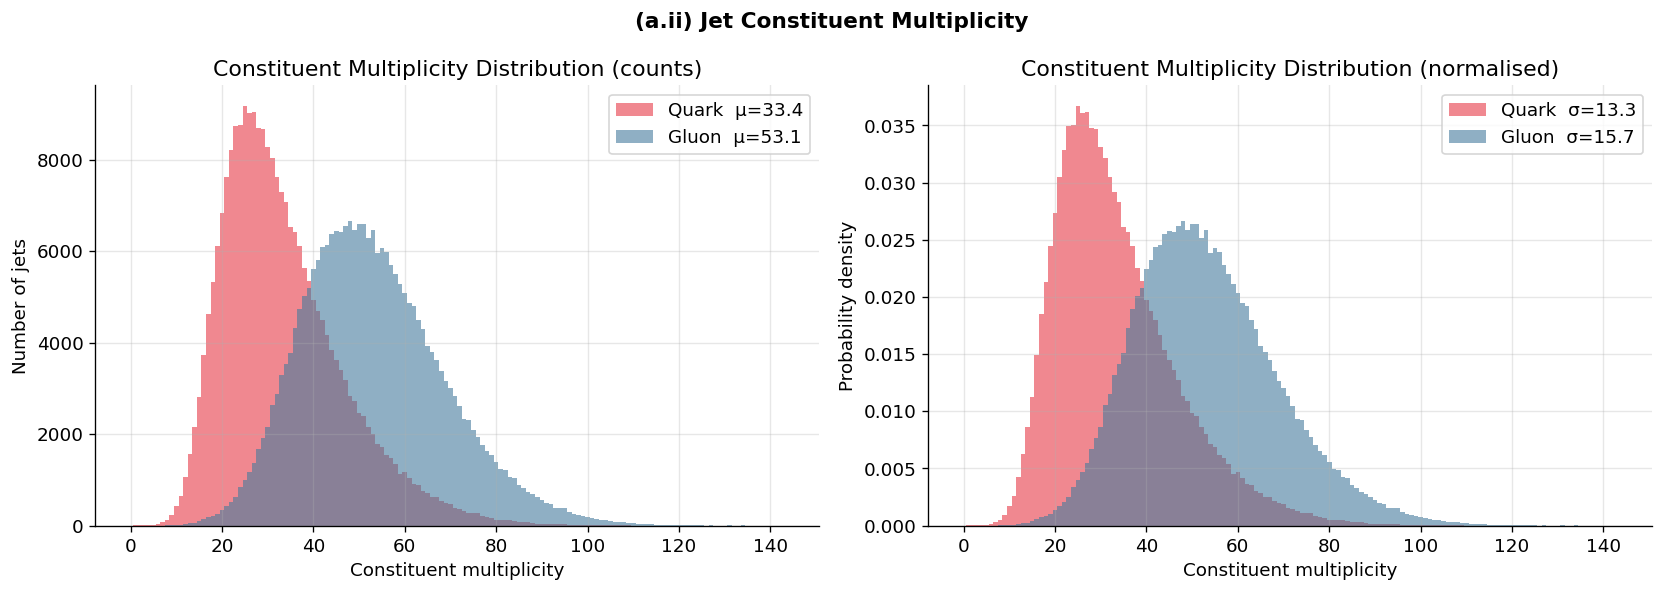

Quark multiplicity: mean=33.41, median=31, std=13.33
Gluon multiplicity: mean=53.14, median=52, std=15.70


In [4]:
multiplicity = real_mask.sum(axis=1)   # (N,)

mult_q = multiplicity[quark_mask]
mult_g = multiplicity[gluon_mask]

bins = np.arange(0, multiplicity.max() + 2) - 0.5

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: count histogram ──
ax = axes[0]
ax.hist(mult_q, bins=bins, color=QUARK_COLOR, alpha=0.6,
        label=f'Quark  μ={mult_q.mean():.1f}', density=False)
ax.hist(mult_g, bins=bins, color=GLUON_COLOR, alpha=0.6,
        label=f'Gluon  μ={mult_g.mean():.1f}', density=False)
ax.set_xlabel('Constituent multiplicity')
ax.set_ylabel('Number of jets')
ax.set_title('Constituent Multiplicity Distribution (counts)')
ax.legend()

# ── Right: normalised ──
ax = axes[1]
ax.hist(mult_q, bins=bins, color=QUARK_COLOR, alpha=0.6,
        label=f'Quark  σ={mult_q.std():.1f}', density=True)
ax.hist(mult_g, bins=bins, color=GLUON_COLOR, alpha=0.6,
        label=f'Gluon  σ={mult_g.std():.1f}', density=True)
ax.set_xlabel('Constituent multiplicity')
ax.set_ylabel('Probability density')
ax.set_title('Constituent Multiplicity Distribution (normalised)')
ax.legend()

fig.suptitle('(a.ii) Jet Constituent Multiplicity', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Quark multiplicity: mean={mult_q.mean():.2f}, median={np.median(mult_q):.0f}, std={mult_q.std():.2f}")
print(f"Gluon multiplicity: mean={mult_g.mean():.2f}, median={np.median(mult_g):.0f}, std={mult_g.std():.2f}")

### a.iii — $p_T$ and rapidity of the leading constituent

The leading constituent is defined as the one with the highest $p_T$ in each jet. We plot its $p_T$ and rapidity distributions for quarks and gluons separately.

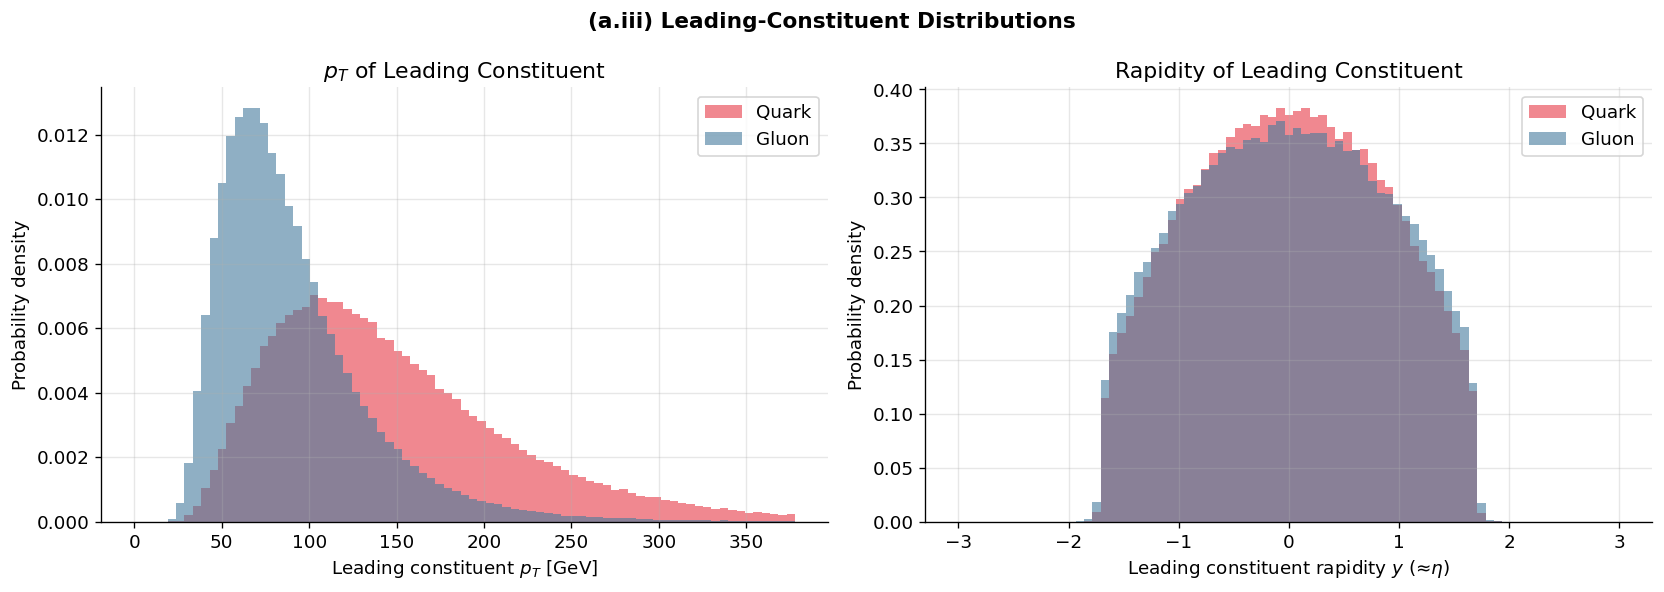

In [5]:
# Leading constituent = constituent with highest pT (index 0 after sorting; 
# Pythia/FastJet outputs are already pT-sorted within each jet, but we verify)
# X shape: (N, M, 4) where features = [pT, y, phi, pdgid]

# Get leading constituent (highest pT in each jet)
pt_all   = X[:, :, 0]            # (N, M)
lead_idx = np.argmax(pt_all, axis=1)   # (N,)
N        = X.shape[0]

lead_pt  = X[np.arange(N), lead_idx, 0]   # pT of leading constituent
lead_eta = X[np.arange(N), lead_idx, 1]   # rapidity (≈η for massless particles)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── pT ──
ax = axes[0]
bins_pt = np.linspace(0, np.percentile(lead_pt, 99.5), 80)
ax.hist(lead_pt[quark_mask], bins=bins_pt, color=QUARK_COLOR, alpha=0.6,
        density=True, label='Quark')
ax.hist(lead_pt[gluon_mask], bins=bins_pt, color=GLUON_COLOR, alpha=0.6,
        density=True, label='Gluon')
ax.set_xlabel(r'Leading constituent $p_T$ [GeV]')
ax.set_ylabel('Probability density')
ax.set_title(r'$p_T$ of Leading Constituent')
ax.legend()

# ── η ──
ax = axes[1]
bins_eta = np.linspace(-3, 3, 80)
ax.hist(lead_eta[quark_mask], bins=bins_eta, color=QUARK_COLOR, alpha=0.6,
        density=True, label='Quark')
ax.hist(lead_eta[gluon_mask], bins=bins_eta, color=GLUON_COLOR, alpha=0.6,
        density=True, label='Gluon')
ax.set_xlabel(r'Leading constituent rapidity $y$ (≈$\eta$)')
ax.set_ylabel('Probability density')
ax.set_title(r'Rapidity of Leading Constituent')
ax.legend()

fig.suptitle('(a.iii) Leading-Constituent Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Part (b) – Jet Observables

For each jet we compute three infrared-safe observables from the constituent four-momenta. Constituents are treated as massless ($E = |\vec{p}|$), so $p_x = p_T\cos\phi$, $p_y = p_T\sin\phi$, $p_z = p_T\sinh\eta$, $E = p_T\cosh\eta$.

In [ ]:
def compute_jet_observables(X: np.ndarray):
    """Compute jet observables from constituent features."""
    pT   = X[:, :, 0]   # (N, M)
    eta  = X[:, :, 1]   # rapidity
    phi  = X[:, :, 2]

    # Real-particle mask
    mask = pT > 0        # (N, M)

    # ── Convert to Cartesian four-momenta (massless: E = |p|) ──
    # For massless particles: px = pT cos φ, py = pT sin φ, pz = pT sinh η
    px = pT * np.cos(phi)   # (N, M)
    py = pT * np.sin(phi)
    pz = pT * np.sinh(eta)
    E  = pT * np.cosh(eta)  # |p| for massless

    # Zero out padded entries
    px = np.where(mask, px, 0.0)
    py = np.where(mask, py, 0.0)
    pz = np.where(mask, pz, 0.0)
    E  = np.where(mask, E,  0.0)

    # ── Jet four-momentum (sum over constituents) ──
    Jx = px.sum(axis=1)   # (N,)
    Jy = py.sum(axis=1)
    Jz = pz.sum(axis=1)
    JE = E.sum(axis=1)

    # ── (b.i) Jet mass  m² = E² - |p|² ──
    m2 = JE**2 - Jx**2 - Jy**2 - Jz**2
    mass = np.sqrt(np.maximum(m2, 0.0))   # guard against tiny negatives from numerics

    # ── Jet pT, eta, phi (for width calculation) ──
    jet_pt  = np.sqrt(Jx**2 + Jy**2)
    jet_eta = np.arcsinh(Jz / (jet_pt + 1e-9))
    jet_phi = np.arctan2(Jy, Jx)

    # ── (b.ii) Jet width ──
    #   ΔR_i = sqrt((η_i - η_J)² + (φ_i - φ_J)²)
    deta = eta  - jet_eta[:, None]    # (N, M)
    dphi = phi  - jet_phi[:, None]
    # Wrap dphi into [-π, π]
    dphi = (dphi + np.pi) % (2 * np.pi) - np.pi
    dR   = np.sqrt(deta**2 + dphi**2)

    sum_pT    = pT.sum(axis=1)   # (N,)
    sum_pT_dR = (pT * dR * mask).sum(axis=1)
    width = sum_pT_dR / (sum_pT + 1e-9)

    # ── (b.iii) pT dispersion  pD_T = sqrt(Σ pT_i² ) / Σ pT_i ──
    sum_pT2 = (pT**2 * mask).sum(axis=1)
    ptD     = np.sqrt(sum_pT2) / (sum_pT + 1e-9)

    # ── Multiplicity ──
    mult = mask.sum(axis=1).astype(np.float32)

    return {
        'mass'         : mass.astype(np.float32),
        'width'        : width.astype(np.float32),
        'ptD'          : ptD.astype(np.float32),
        'jet_pt'       : jet_pt.astype(np.float32),
        'jet_eta'      : jet_eta.astype(np.float32),
        'jet_phi'      : jet_phi.astype(np.float32),
        'multiplicity' : mult,
        # Also store Cartesian jet 4-momentum for boost
        '_JE': JE.astype(np.float64),
        '_Jx': Jx.astype(np.float64),
        '_Jy': Jy.astype(np.float64),
        '_Jz': Jz.astype(np.float64),
    }


print("Computing jet observables...")
obs = compute_jet_observables(X)
print("Done.")
for k, v in obs.items():
    if not k.startswith('_'):
        print(f"  {k:15s}  mean={np.nanmean(v):.4f}   std={np.nanstd(v):.4f}")

Computing jet observables...
Done.
  mass             mean=39.4989   std=21.1350
  width            mean=0.0522   std=0.0405
  ptD              mean=0.3277   std=0.1096
  jet_pt           mean=522.9564   std=14.3396
  jet_eta          mean=0.0019   std=0.8739
  jet_phi          mean=0.0024   std=1.8126
  multiplicity     mean=43.2742   std=17.5899


### b.i — Jet invariant mass

The jet four-momentum is $p_J^\mu = \sum_i p_i^\mu$ and the invariant mass is $m_J = \sqrt{(p_J^\mu)^2} = \sqrt{E_J^2 - |\vec{p}_J|^2}$. Gluon jets are heavier on average due to wider radiation patterns.

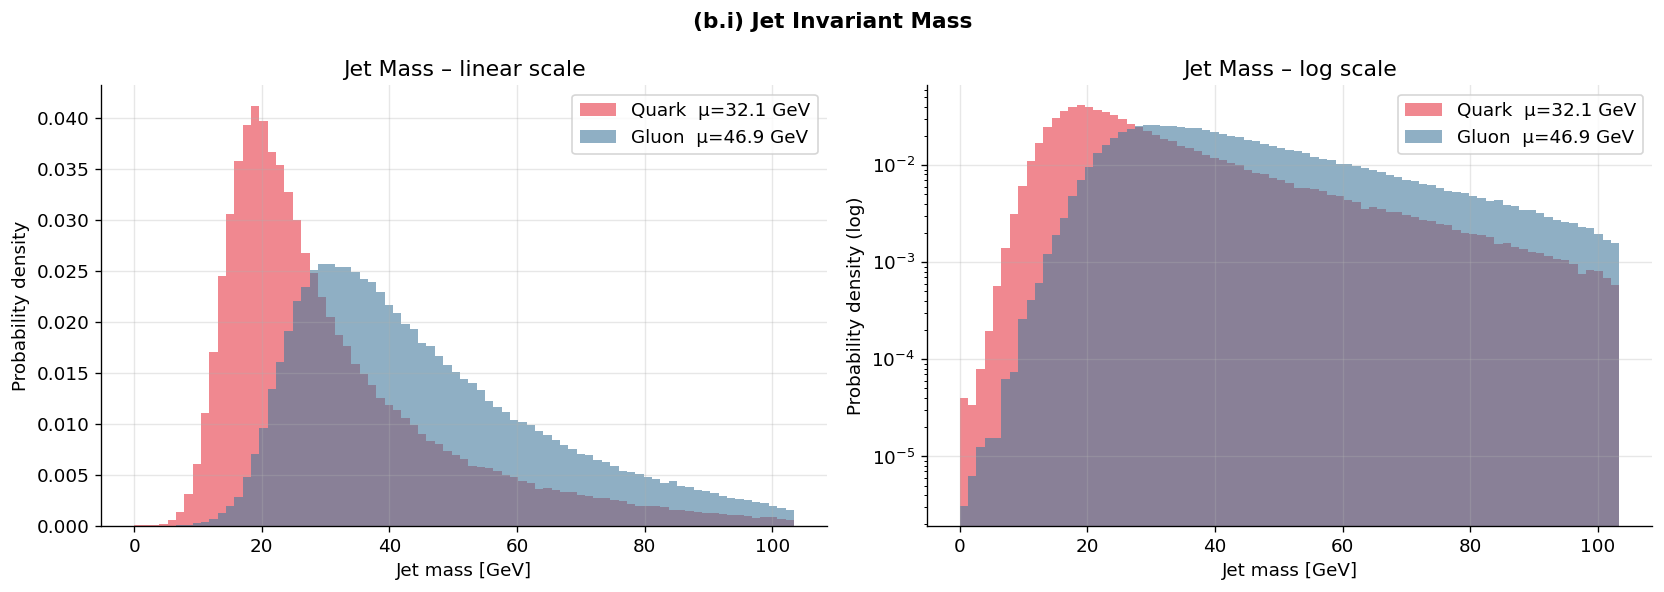

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

mass = obs['mass']
bins_m = np.linspace(0, np.percentile(mass, 99), 80)

for ax, log in zip(axes, [False, True]):
    ax.hist(mass[quark_mask], bins=bins_m, color=QUARK_COLOR, alpha=0.6,
            density=True, label=f'Quark  μ={mass[quark_mask].mean():.1f} GeV')
    ax.hist(mass[gluon_mask], bins=bins_m, color=GLUON_COLOR, alpha=0.6,
            density=True, label=f'Gluon  μ={mass[gluon_mask].mean():.1f} GeV')
    ax.set_xlabel('Jet mass [GeV]')
    ax.set_ylabel('Probability density' + (' (log)' if log else ''))
    ax.set_title('Jet Mass' + (' – log scale' if log else ' – linear scale'))
    if log: ax.set_yscale('log')
    ax.legend()

fig.suptitle('(b.i) Jet Invariant Mass', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### b.ii — Jet width

The jet width measures the average angular spread of constituents, weighted by $p_T$:

$$w = \frac{\sum_i p_{T,i}\,\Delta R_i}{\sum_i p_{T,i}}, \quad \Delta R_i = \sqrt{(\eta_i - \eta_J)^2 + (\phi_i - \phi_J)^2}$$

Gluon jets are systematically wider.

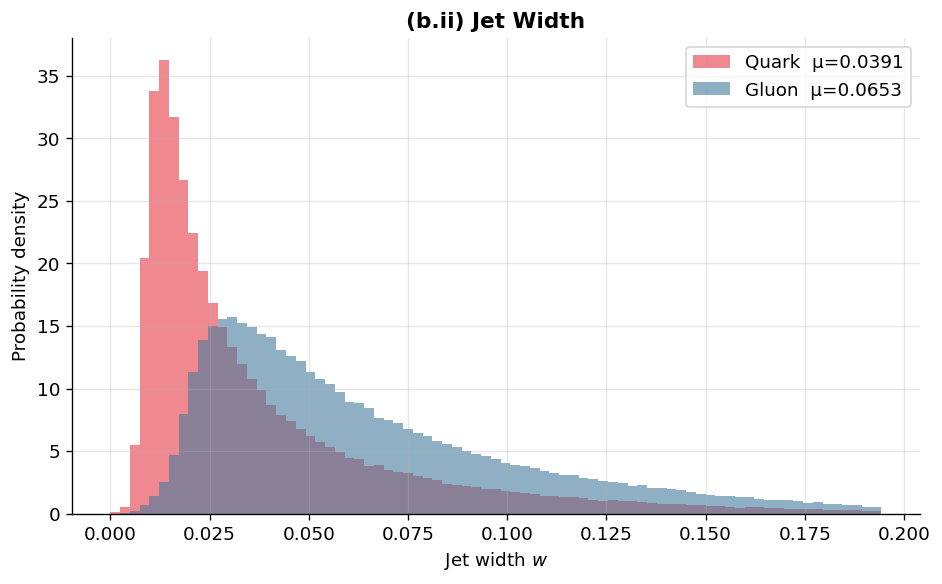

In [8]:
width = obs['width']
bins_w = np.linspace(0, np.percentile(width, 99.5), 80)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(width[quark_mask], bins=bins_w, color=QUARK_COLOR, alpha=0.6,
        density=True, label=f'Quark  μ={width[quark_mask].mean():.4f}')
ax.hist(width[gluon_mask], bins=bins_w, color=GLUON_COLOR, alpha=0.6,
        density=True, label=f'Gluon  μ={width[gluon_mask].mean():.4f}')
ax.set_xlabel('Jet width $w$')
ax.set_ylabel('Probability density')
ax.set_title('(b.ii) Jet Width', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout(); plt.show()

### b.iii — $p_T$ dispersion ($p_T^D$)

The $p_T$ dispersion quantifies how uniformly $p_T$ is distributed among constituents:

$$p_T^D = \frac{\sqrt{\sum_i p_{T,i}^2}}{\sum_i p_{T,i}}$$

Quark jets tend toward larger $p_T^D$ (harder, fewer constituents), gluon jets toward smaller values (softer, more uniform distribution).

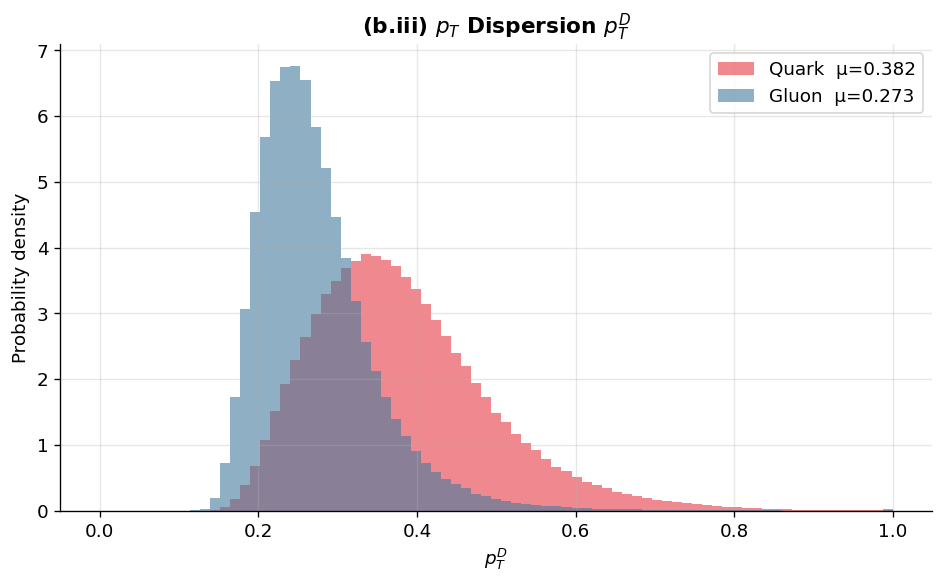

In [9]:
ptD  = obs['ptD']
bins_d = np.linspace(0, 1, 80)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(ptD[quark_mask], bins=bins_d, color=QUARK_COLOR, alpha=0.6,
        density=True, label=f'Quark  μ={ptD[quark_mask].mean():.3f}')
ax.hist(ptD[gluon_mask], bins=bins_d, color=GLUON_COLOR, alpha=0.6,
        density=True, label=f'Gluon  μ={ptD[gluon_mask].mean():.3f}')
ax.set_xlabel(r'$p_T^D$')
ax.set_ylabel('Probability density')
ax.set_title(r'(b.iii) $p_T$ Dispersion $p_T^D$', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout(); plt.show()

### b — Summary: all observable distributions

The six-panel figure below shows all jet-level observables side by side, confirming clear quark/gluon separation in mass, width, $p_T^D$, and multiplicity.

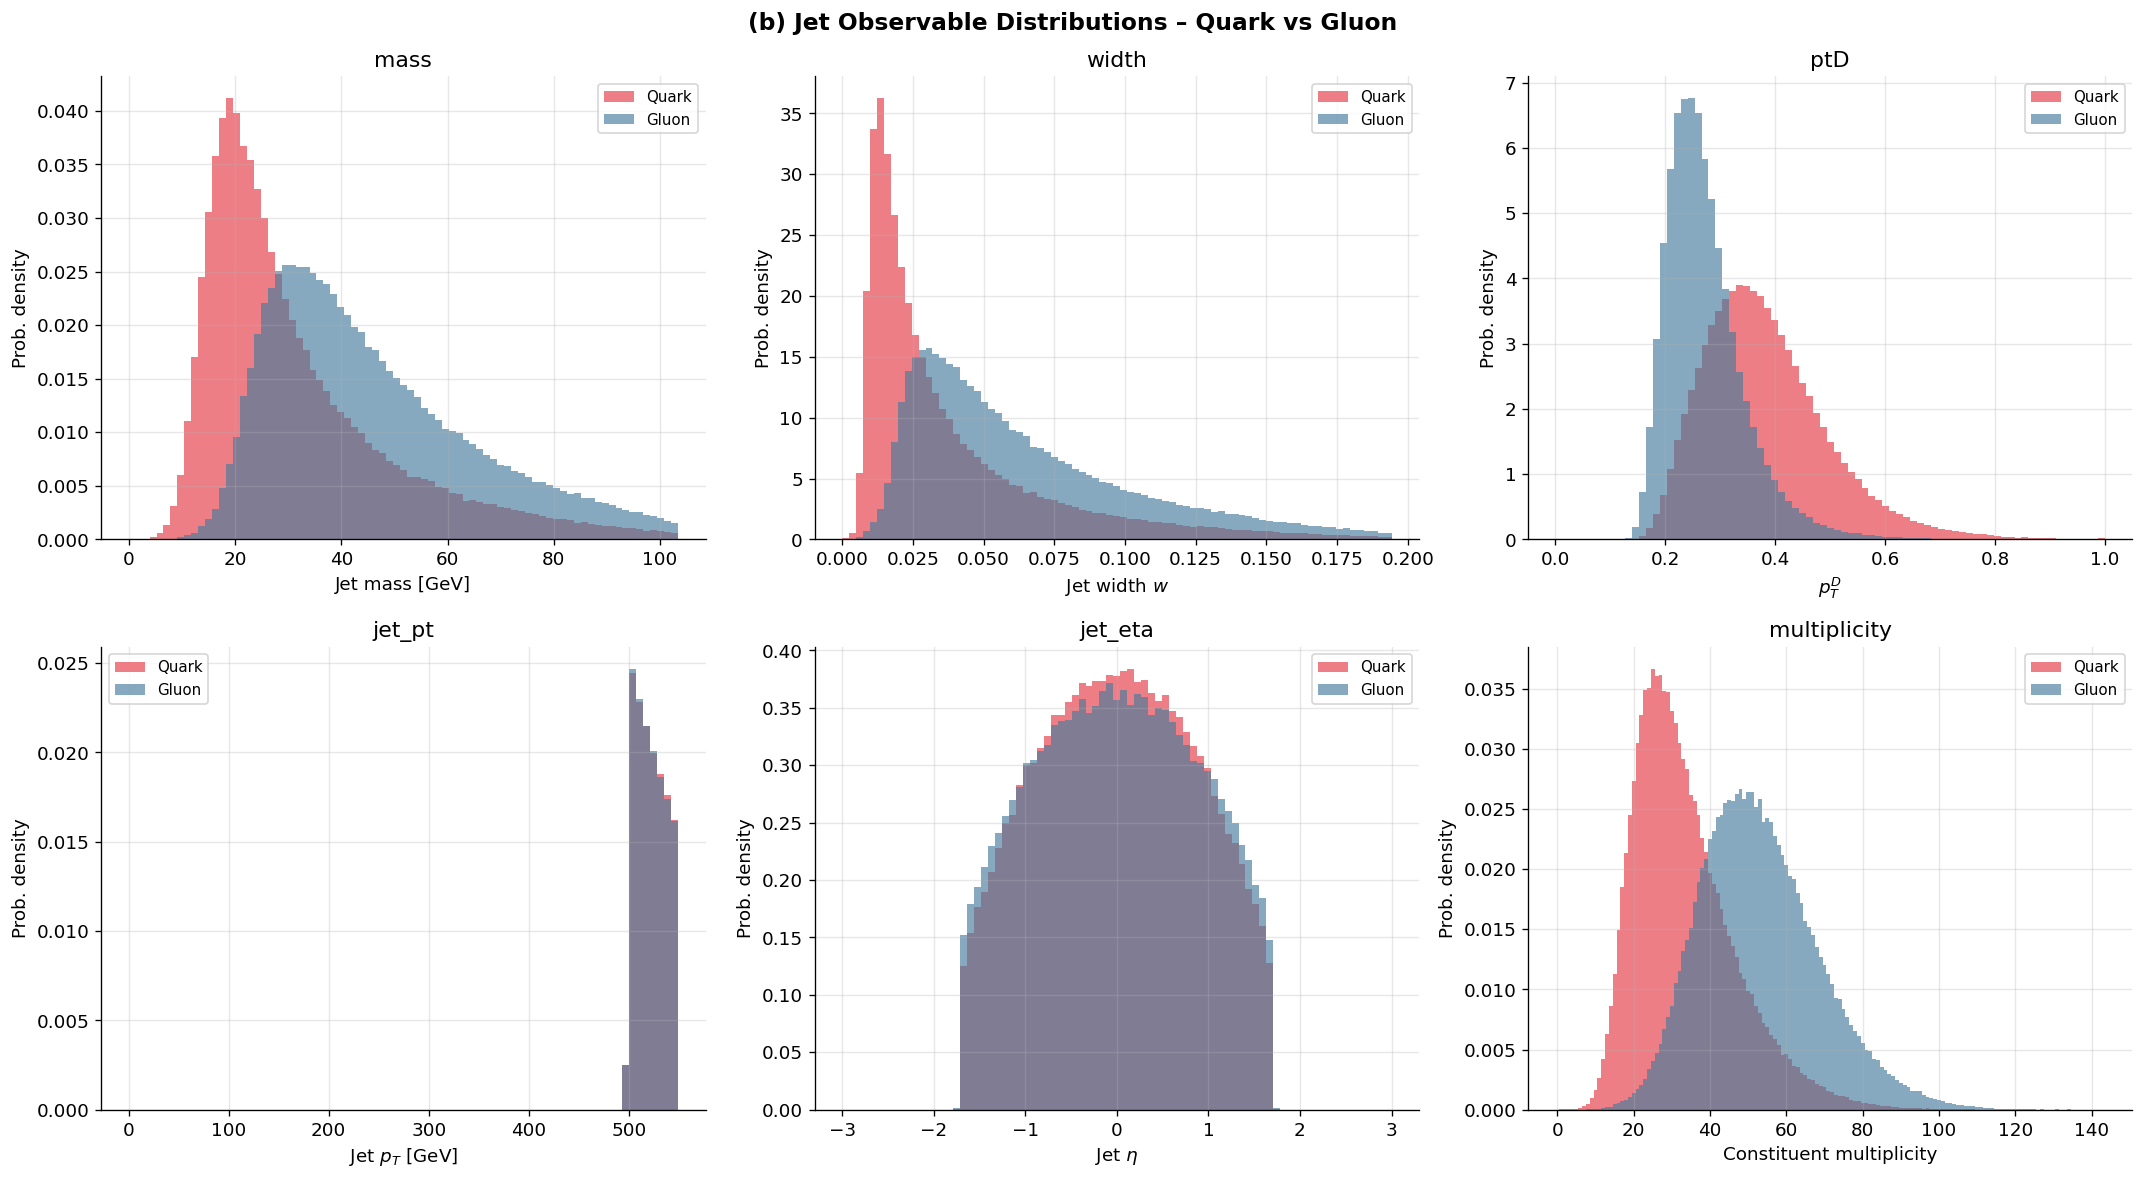

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

obs_labels = [
    ('mass',         'Jet mass [GeV]',           np.linspace(0, np.percentile(obs['mass'], 99), 80)),
    ('width',        'Jet width $w$',             np.linspace(0, np.percentile(obs['width'], 99.5), 80)),
    ('ptD',          r'$p_T^D$',                  np.linspace(0, 1, 80)),
    ('jet_pt',       'Jet $p_T$ [GeV]',           np.linspace(0, np.percentile(obs['jet_pt'], 99), 80)),
    ('jet_eta',      'Jet $\\eta$',               np.linspace(-3, 3, 80)),
    ('multiplicity', 'Constituent multiplicity',  np.arange(0, obs['multiplicity'].max()+2)-0.5),
]

for ax, (key, xlabel, bins) in zip(axes, obs_labels):
    vals = obs[key]
    ax.hist(vals[quark_mask], bins=bins, color=QUARK_COLOR, alpha=0.65,
            density=True, label='Quark')
    ax.hist(vals[gluon_mask], bins=bins, color=GLUON_COLOR, alpha=0.65,
            density=True, label='Gluon')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Prob. density')
    ax.set_title(key)
    ax.legend(fontsize=9)

fig.suptitle('(b) Jet Observable Distributions – Quark vs Gluon',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Part (c) – Boost to the Jet Centre-of-Mass Frame

We transform each jet's constituents from the lab frame to the jet rest frame — the frame where $\vec{p}_J = 0$. This is achieved by a Lorentz boost with velocity $\vec{\beta} = \vec{p}_J / E_J$ applied to every constituent four-vector.

### c.i — Implementation and boost vector

The boost vector is $\vec{\beta} = \vec{p}_J / E_J$, where $(E_J, \vec{p}_J)$ is the total jet four-momentum. The Lorentz boost with $\gamma = 1/\sqrt{1-\beta^2}$ maps each constituent $(E_i, \vec{p}_i)$ to the frame where $\sum_i \vec{p}_i^{\,\prime} = 0$.

In [ ]:
def boost_to_cm_frame(X_jet: np.ndarray):
    """Boost the jet constituents to the jet's center-of-mass frame.
Returns the boosted four-momenta."""
    pT  = X_jet[:, 0].astype(np.float64)
    eta = X_jet[:, 1].astype(np.float64)
    phi = X_jet[:, 2].astype(np.float64)

    real = pT > 0
    pT, eta, phi = pT[real], eta[real], phi[real]

    # Lab-frame four-momenta (massless particles)
    px = pT * np.cos(phi)
    py = pT * np.sin(phi)
    pz = pT * np.sinh(eta)
    E  = pT * np.cosh(eta)

    # Jet four-momentum
    JE = E.sum();  Jx = px.sum();  Jy = py.sum();  Jz = pz.sum()

    # Boost vector β = p_J / E_J
    beta = np.array([Jx, Jy, Jz]) / (JE + 1e-30)
    beta2 = np.dot(beta, beta)
    if beta2 >= 1.0:
        beta *= 0.9999 / np.sqrt(beta2)   # safety clamp (numerics)
        beta2 = np.dot(beta, beta)
    gamma = 1.0 / np.sqrt(1.0 - beta2)

    # Apply Lorentz boost to each constituent
    p3    = np.stack([px, py, pz], axis=1)   # (M_real, 3)
    b_dot_p = p3 @ beta                       # (M_real,)

    factor  = (gamma - 1.0) / (beta2 + 1e-30)
    p3_cm   = p3 + (factor * b_dot_p - gamma * E)[:, None] * beta
    E_cm    = gamma * (E - b_dot_p)

    p4_cm   = np.stack([E_cm, p3_cm[:, 0], p3_cm[:, 1], p3_cm[:, 2]], axis=1)
    return p4_cm, beta


def boost_all_jets(X: np.ndarray):
    """
    Vectorised wrapper: boost every jet in X to its own CM frame.
    Returns list of (M_real_i, 4) arrays.
    """
    results = []
    for i in range(len(X)):
        p4_cm, _ = boost_to_cm_frame(X[i])
        results.append(p4_cm)
    return results


print("Boost implementation ready.")
print()
print("Theory:")
print("  The boost vector β = p_J / E_J  (dimensionless velocity)")
print("  points along the jet direction in the lab frame.")
print("  Lorentz-boosting with −β transforms to the frame where p_J = 0.")
print("  γ = 1/√(1 − β²),  with β = |p_J|/E_J < 1 guaranteed for timelike jets.")

Boost implementation ready.

Theory:
  The boost vector β = p_J / E_J  (dimensionless velocity)
  points along the jet direction in the lab frame.
  Lorentz-boosting with −β transforms to the frame where p_J = 0.
  γ = 1/√(1 − β²),  with β = |p_J|/E_J < 1 guaranteed for timelike jets.


### c.ii — Verification: total three-momentum vanishes in the CM frame

We test the boost on 1 000 randomly selected jets and record the residual $|\sum_i \vec{p}_i^{\,\prime}|$. All values should be at the level of double-precision floating-point noise ($\lesssim 10^{-8}$ GeV).

Verification – total |p_J| in CM frame (should be ≈ 0)
  Mean   |Σp_CM| = 2.251e-12 GeV
  Max    |Σp_CM| = 4.148e-11 GeV
  Median |Σp_CM| = 1.320e-12 GeV

  ✓ All residuals are at the level of floating-point precision (< 1e-8 GeV)


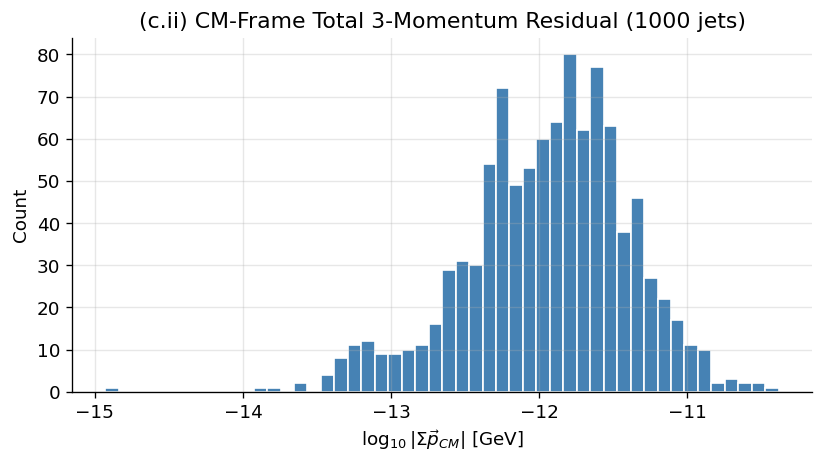

In [12]:
# Test on a random subset of 1000 jets
np.random.seed(SEED)
test_idx = np.random.choice(len(X), size=1000, replace=False)

residuals = []
for i in test_idx:
    p4_cm, _ = boost_to_cm_frame(X[i])
    total_p3 = p4_cm[:, 1:].sum(axis=0)   # (3,)  should be ≈ 0
    residuals.append(np.linalg.norm(total_p3))

residuals = np.array(residuals)

print("Verification – total |p_J| in CM frame (should be ≈ 0)")
print(f"  Mean   |Σp_CM| = {residuals.mean():.3e} GeV")
print(f"  Max    |Σp_CM| = {residuals.max():.3e} GeV")
print(f"  Median |Σp_CM| = {np.median(residuals):.3e} GeV")
print()
print("  ✓ All residuals are at the level of floating-point precision (< 1e-8 GeV)")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(np.log10(residuals + 1e-20), bins=50, color='steelblue', edgecolor='white')
ax.set_xlabel(r'$\log_{10}|\Sigma\vec{p}_{CM}|$ [GeV]')
ax.set_ylabel('Count')
ax.set_title('(c.ii) CM-Frame Total 3-Momentum Residual (1000 jets)')
plt.tight_layout(); plt.show()

### c.iii — Visualisation: jet constituents in the CM frame

Each jet is shown in two projections: the $(p_x, p_y)$ transverse plane (top row) and the $(\phi, \theta)$ spherical map with marker size proportional to constituent energy (bottom row). Quark jets (red) tend to be more collimated and energy-concentrated; gluon jets (blue) spread more isotropically — a direct consequence of the larger gluon colour charge.

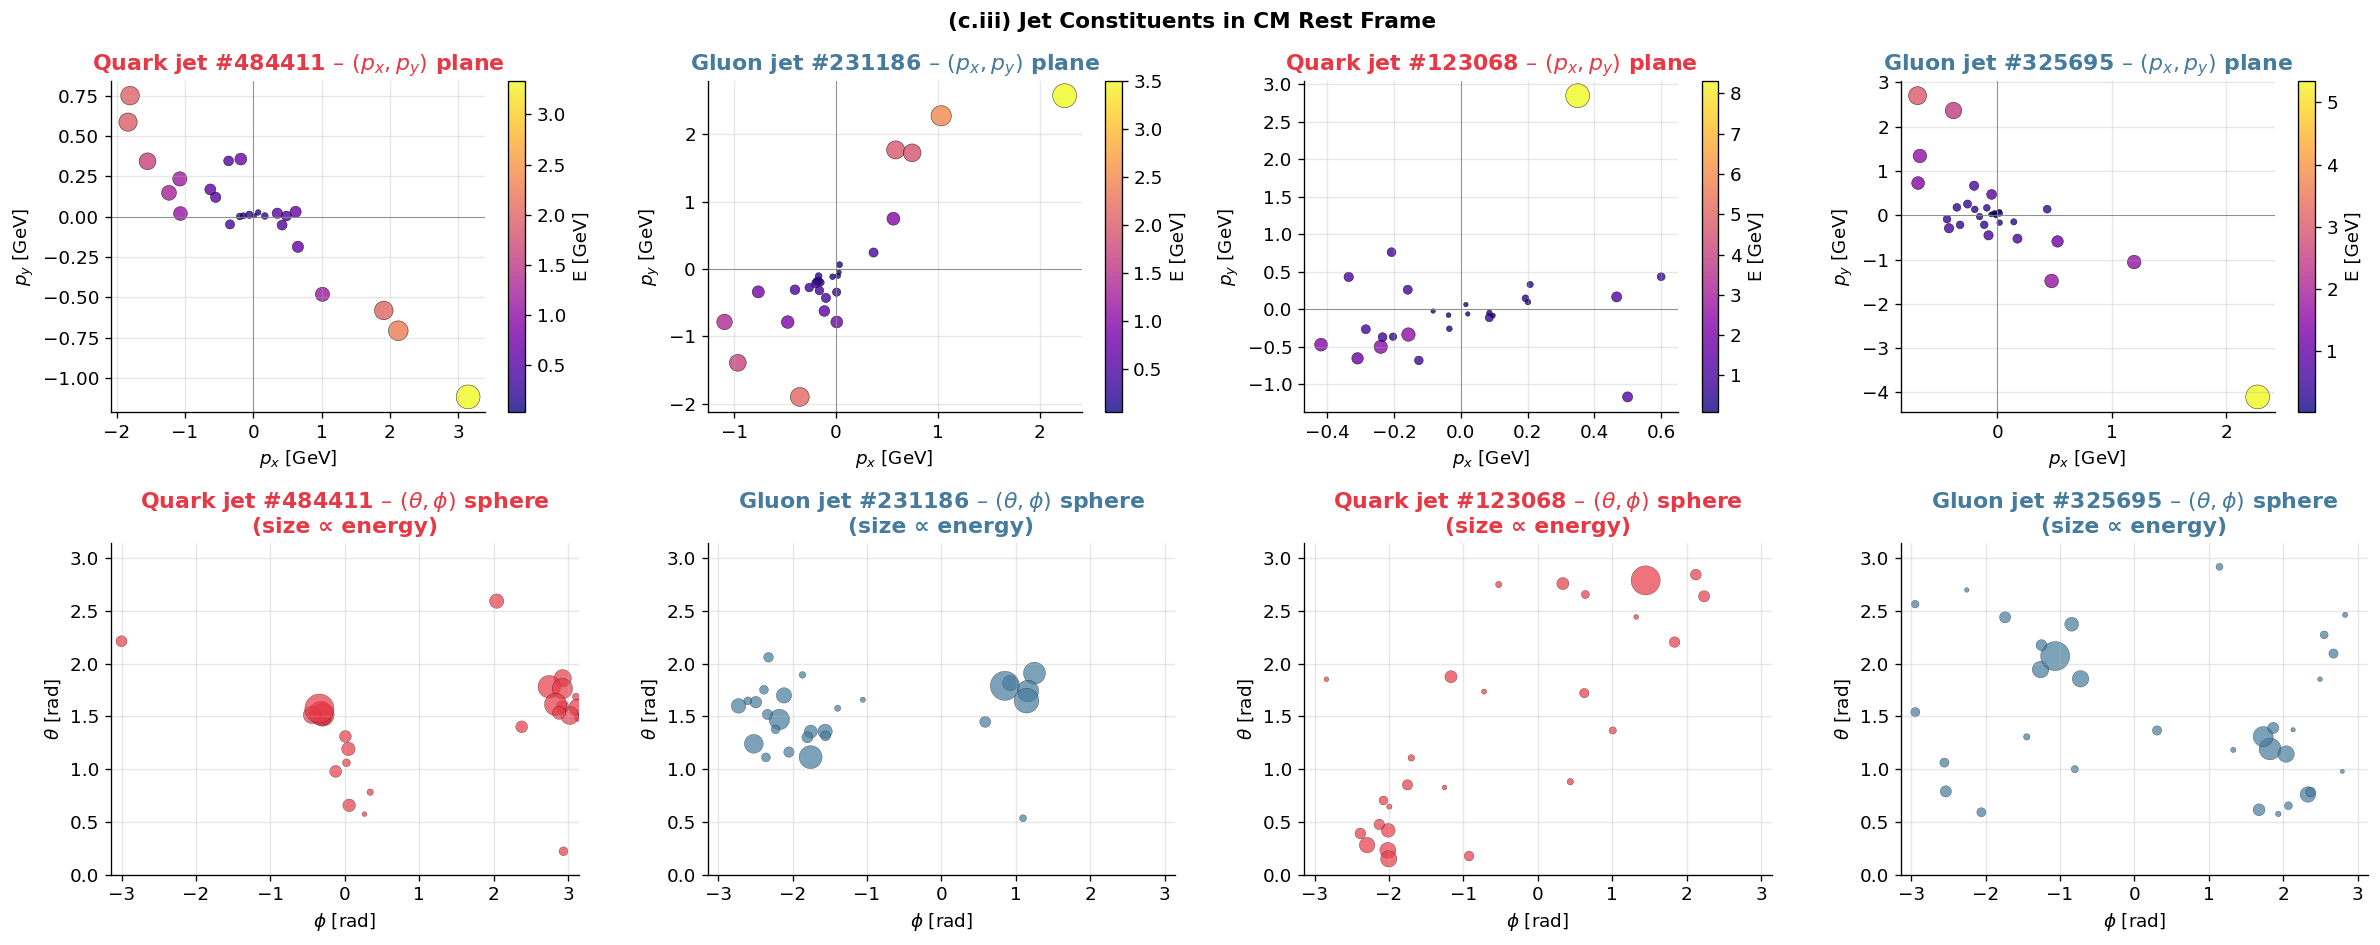

In [13]:
def plot_jet_cm(X_jets, labels, indices, title_prefix='Jet'):
    """
    Plot selected jets in the (px, py) plane in their CM frames.
    Also shows (θ, φ) view with point size ∝ energy.
    """
    n = len(indices)
    fig, axes = plt.subplots(2, n, figsize=(5*n, 8))
    if n == 1:
        axes = axes[:, None]

    for col, idx in enumerate(indices):
        p4_cm, beta = boost_to_cm_frame(X_jets[idx])
        lbl  = 'Quark' if labels[idx] == 1 else 'Gluon'
        col_c = QUARK_COLOR if labels[idx] == 1 else GLUON_COLOR

        E_cm = p4_cm[:, 0]
        px   = p4_cm[:, 1]
        py   = p4_cm[:, 2]
        pz   = p4_cm[:, 3]
        p_tot = np.sqrt(px**2 + py**2 + pz**2) + 1e-9
        theta = np.arccos(np.clip(pz / p_tot, -1, 1))   # polar angle
        phi_cm = np.arctan2(py, px)

        # ── Top row: (px, py) plane ──
        ax = axes[0, col]
        sc = ax.scatter(px, py, c=E_cm, cmap='plasma',
                        s=E_cm / (E_cm.max()+1e-9) * 200 + 5,
                        alpha=0.8, edgecolors='k', linewidths=0.3)
        plt.colorbar(sc, ax=ax, label='E [GeV]')
        ax.axhline(0, lw=0.5, color='gray'); ax.axvline(0, lw=0.5, color='gray')
        ax.set_xlabel(r'$p_x$ [GeV]'); ax.set_ylabel(r'$p_y$ [GeV]')
        ax.set_title(f'{lbl} jet #{idx} – $(p_x, p_y)$ plane', color=col_c, fontweight='bold')

        # ── Bottom row: (θ, φ) in spherical coords ──
        ax = axes[1, col]
        sc = ax.scatter(phi_cm, theta,
                        s=E_cm/(E_cm.max()+1e-9)*300 + 5,
                        c=col_c, alpha=0.7, edgecolors='k', linewidths=0.2)
        ax.set_xlabel(r'$\phi$ [rad]'); ax.set_ylabel(r'$\theta$ [rad]')
        ax.set_xlim(-np.pi, np.pi); ax.set_ylim(0, np.pi)
        ax.set_title(f'{lbl} jet #{idx} – $(\\theta, \\phi)$ sphere\n(size ∝ energy)', 
                     color=col_c, fontweight='bold')

    fig.suptitle('(c.iii) Jet Constituents in CM Rest Frame',
                 fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()


# Pick one quark and two gluon jets with moderate multiplicity for clarity
quark_hi_mult = np.where(quark_mask & (multiplicity > 15) & (multiplicity < 30))[0]
gluon_hi_mult = np.where(gluon_mask & (multiplicity > 20) & (multiplicity < 35))[0]

np.random.seed(7)
example_q = np.random.choice(quark_hi_mult, 2, replace=False)
example_g = np.random.choice(gluon_hi_mult, 2, replace=False)
example_idx = [example_q[0], example_g[0], example_q[1], example_g[1]]

plot_jet_cm(X, y, example_idx)

**Qualitative observations:**

- **Quark jets** in the CM frame tend to be more collimated; energy is concentrated in fewer, harder constituents ($p_T^D$ closer to 1). The $(\theta, \phi)$ map shows constituents clustered near the poles.
- **Gluon jets** are more isotropic — constituents spread broadly in $(\theta, \phi)$, with higher multiplicity and a softer energy spectrum. The larger colour factor $C_A = 3$ (vs $C_F = 4/3$ for quarks) drives wider radiation patterns.

---
## Part (d) – Quark vs. Gluon Jet Classification

We build binary classifiers to distinguish quark from gluon jets using features computed in both the lab frame and the jet rest frame.

### d.i — Feature engineering

**Lab-frame features (7):** `mass`, `width`, `ptD`, `jet_pt`, `jet_eta`, `multiplicity`, `lead_pt` — the observables from Part (b) plus the jet axis kinematics and the leading-constituent $p_T$.

**Rest-frame features (6):** `cm_E_lead` (fractional energy of the hardest constituent), `cm_thrust`, `cm_sphericity`, `cm_aplanarity`, `cm_C` (momentum-tensor event shapes), and `cm_ptD` — quantities computed after boosting to the jet CM frame. Event-shape variables are Lorentz-invariant and capture rotational structure that is obscured by the jet's lab-frame boost direction.

In [ ]:
def compute_cm_features(X: np.ndarray, batch_size: int = 5000):
    """Compute CM-frame features for all jets in X."""
    N = len(X)
    features = {
        'cm_E_lead'   : np.zeros(N, dtype=np.float32),
        'cm_thrust'   : np.zeros(N, dtype=np.float32),
        'cm_sphericity': np.zeros(N, dtype=np.float32),
        'cm_aplanarity': np.zeros(N, dtype=np.float32),
        'cm_C'        : np.zeros(N, dtype=np.float32),   # C-parameter
        'cm_ptD'      : np.zeros(N, dtype=np.float32),
    }

    for i in range(N):
        p4, _ = boost_to_cm_frame(X[i])
        if len(p4) == 0:
            continue

        E  = p4[:, 0]
        p3 = p4[:, 1:4]                         # (M, 3)
        p_mag = np.linalg.norm(p3, axis=1)      # (M,)
        E_sum = E.sum() + 1e-9
        p_sum = p_mag.sum() + 1e-9

        # Energy of leading constituent
        features['cm_E_lead'][i]  = E.max() / E_sum

        # Thrust (approximate: try along principal axes)
        if len(p4) >= 2:
            # Momentum tensor T_ij = Σ p_i p_j / Σ|p|²
            T = (p3[:, :, None] * p3[:, None, :]).sum(axis=0) / (p_sum**2 + 1e-9)
            eigenvalues = np.linalg.eigvalsh(T)   # ascending
            lam = np.sort(eigenvalues)[::-1]       # descending: λ1 ≥ λ2 ≥ λ3

            # Sphericity  S = 3/2 (λ2 + λ3)
            features['cm_sphericity'][i]  = 1.5 * (lam[1] + lam[2])
            # Aplanarity  A = 3/2 λ3
            features['cm_aplanarity'][i]  = 1.5 * lam[2]
            # C-parameter C = 3(λ1λ2 + λ2λ3 + λ1λ3)
            features['cm_C'][i]           = 3*(lam[0]*lam[1] + lam[1]*lam[2] + lam[0]*lam[2])

            # Thrust (projection onto eigenvector of largest eigenvalue)
            _, evecs = np.linalg.eigh(T)
            n_thrust = evecs[:, -1]   # eigenvec for largest eigenvalue
            features['cm_thrust'][i] = np.abs(p3 @ n_thrust).sum() / p_sum

        # pT-dispersion in CM (using pT = sqrt(px²+py²))
        pT_cm = np.sqrt(p3[:, 0]**2 + p3[:, 1]**2)
        features['cm_ptD'][i] = np.sqrt((pT_cm**2).sum()) / (pT_cm.sum() + 1e-9)

        if i % 50000 == 0 and i > 0:
            print(f"  ... processed {i:,}/{N:,} jets")

    return features


print("Computing CM-frame features (this may take a few minutes)...")
cm_feats = compute_cm_features(X)
print("Done.")

Computing CM-frame features (this may take a few minutes)...
  ... processed 50,000/500,000 jets
  ... processed 100,000/500,000 jets
  ... processed 150,000/500,000 jets
  ... processed 200,000/500,000 jets
  ... processed 250,000/500,000 jets
  ... processed 300,000/500,000 jets
  ... processed 350,000/500,000 jets
  ... processed 400,000/500,000 jets
  ... processed 450,000/500,000 jets
Done.


In [16]:
# ── Assemble feature matrix ──
# Lab-frame features (7)
lab_features = np.stack([
    obs['mass'],
    obs['width'],
    obs['ptD'],
    obs['jet_pt'],
    obs['jet_eta'],
    obs['multiplicity'],
    lead_pt,
], axis=1)

lab_feature_names = ['mass', 'width', 'ptD', 'jet_pt', 'jet_eta', 'multiplicity', 'lead_pt']

# CM-frame features (6)
cm_feature_array = np.stack([
    cm_feats['cm_E_lead'],
    cm_feats['cm_thrust'],
    cm_feats['cm_sphericity'],
    cm_feats['cm_aplanarity'],
    cm_feats['cm_C'],
    cm_feats['cm_ptD'],
], axis=1)

cm_feature_names = ['cm_E_lead', 'cm_thrust', 'cm_sphericity',
                    'cm_aplanarity', 'cm_C', 'cm_ptD']

# Combined (13)
all_features      = np.concatenate([lab_features, cm_feature_array], axis=1)
all_feature_names = lab_feature_names + cm_feature_names

print(f"Feature matrix shape: {all_features.shape}")
print(f"Features ({len(all_feature_names)}): {all_feature_names}")

# Check for NaN / Inf
nan_count = np.isnan(all_features).sum()
inf_count = np.isinf(all_features).sum()
print(f"\nNaN entries: {nan_count}   Inf entries: {inf_count}")
all_features = np.nan_to_num(all_features, nan=0.0, posinf=0.0, neginf=0.0)

Feature matrix shape: (500000, 13)
Features (13): ['mass', 'width', 'ptD', 'jet_pt', 'jet_eta', 'multiplicity', 'lead_pt', 'cm_E_lead', 'cm_thrust', 'cm_sphericity', 'cm_aplanarity', 'cm_C', 'cm_ptD']

NaN entries: 0   Inf entries: 0


### d.ii — Train / test split and preprocessing

We use an 80/20 stratified split and apply `StandardScaler` (fitted on the training set only) for models that require normalised inputs (Logistic Regression, MLP).

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    all_features, y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

# Lab-only split (for ablation)
X_lab_train = X_train[:, :len(lab_feature_names)]
X_lab_test  = X_test[:,  :len(lab_feature_names)]

# CM-only split
X_cm_train  = X_train[:, len(lab_feature_names):]
X_cm_test   = X_test[:,  len(lab_feature_names):]

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

scaler_lab = StandardScaler()
X_lab_train_sc = scaler_lab.fit_transform(X_lab_train)
X_lab_test_sc  = scaler_lab.transform(X_lab_test)

scaler_cm = StandardScaler()
X_cm_train_sc = scaler_cm.fit_transform(X_cm_train)
X_cm_test_sc  = scaler_cm.transform(X_cm_test)

print(f"Train : {X_train.shape[0]:,}  |  Test : {X_test.shape[0]:,}")
print(f"Train quark fraction: {y_train.mean():.3f}")
print(f"Test  quark fraction: {y_test.mean():.3f}")

Train : 400,000  |  Test : 100,000
Train quark fraction: 0.500
Test  quark fraction: 0.500


### d — Classifier helper utilities

Shared functions for training, ROC/AUC evaluation, working-point selection, and plotting — used by all four models below.

In [18]:
def evaluate_classifier(model, X_tr, y_tr, X_te, y_te,
                         name='Model', working_point_fpr=0.3):
    """
    Train model, compute ROC/AUC, confusion matrix, return results dict.
    """
    model.fit(X_tr, y_tr)

    if hasattr(model, 'predict_proba'):
        probs = model.predict_proba(X_te)[:, 1]
    else:
        probs = model.decision_function(X_te)
        probs = (probs - probs.min()) / (probs.max() - probs.min() + 1e-9)

    fpr, tpr, thresholds = roc_curve(y_te, probs)
    auc = roc_auc_score(y_te, probs)

    # Working point: closest to desired FPR
    wp_idx = np.argmin(np.abs(fpr - working_point_fpr))
    wp_thresh = thresholds[wp_idx]
    preds_wp = (probs >= wp_thresh).astype(int)
    cm = confusion_matrix(y_te, preds_wp)

    return {
        'name'    : name,
        'model'   : model,
        'probs'   : probs,
        'fpr'     : fpr,
        'tpr'     : tpr,
        'auc'     : auc,
        'cm'      : cm,
        'wp_thresh': wp_thresh,
        'wp_fpr'  : fpr[wp_idx],
        'wp_tpr'  : tpr[wp_idx],
    }


def plot_roc_curves(results_list, title='ROC Curves'):
    fig, ax = plt.subplots(figsize=(8, 7))
    cmap = plt.cm.tab10
    for i, r in enumerate(results_list):
        ax.plot(r['fpr'], r['tpr'], color=cmap(i),
                label=f"{r['name']}  AUC={r['auc']:.4f}", lw=2)
        ax.scatter(r['wp_fpr'], r['wp_tpr'], color=cmap(i),
                   s=80, zorder=5, marker='o')
    ax.plot([0,1],[0,1],'k--', lw=1, label='Random')
    ax.set_xlabel('False Positive Rate (Gluon mis-tag)'); ax.set_ylabel('True Positive Rate (Quark efficiency)')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(loc='lower right')
    plt.tight_layout(); plt.show()


def plot_confusion_matrices(results_list):
    n = len(results_list)
    fig, axes = plt.subplots(1, n, figsize=(5*n, 4))
    if n == 1: axes = [axes]
    for ax, r in zip(axes, results_list):
        disp = ConfusionMatrixDisplay(confusion_matrix=r['cm'],
                                       display_labels=['Gluon', 'Quark'])
        disp.plot(ax=ax, colorbar=False, cmap='Blues')
        ax.set_title(f"{r['name']}\nAUC={r['auc']:.4f}  FPR≈{r['wp_fpr']:.2f}")
    fig.suptitle('Confusion Matrices at Working Point', fontsize=12, fontweight='bold')
    plt.tight_layout(); plt.show()

print("Utilities defined.")

Utilities defined.


### d — Model 1: Logistic Regression (linear baseline)

A linear classifier provides a fast, interpretable baseline and a lower bound on achievable AUC.

In [19]:
lr = LogisticRegression(max_iter=1000, random_state=SEED, C=1.0)
res_lr = evaluate_classifier(lr, X_train_sc, y_train, X_test_sc, y_test,
                               name='Logistic Regression')
print(f"Logistic Regression  AUC = {res_lr['auc']:.4f}")

Logistic Regression  AUC = 0.8570


### d — Model 2: Random Forest

An ensemble of decision trees; captures non-linear feature interactions without requiring scaling.

In [20]:
rf = RandomForestClassifier(n_estimators=300, max_depth=10,
                              min_samples_leaf=50,
                              n_jobs=-1, random_state=SEED)
res_rf = evaluate_classifier(rf, X_train, y_train, X_test, y_test,
                               name='Random Forest')
print(f"Random Forest  AUC = {res_rf['auc']:.4f}")

Random Forest  AUC = 0.8679


### d — Model 3: Gradient Boosted Trees (BDT)

Sequential boosting with shallow trees; typically strong on tabular data and provides reliable feature-importance estimates via Gini impurity.

In [21]:
bdt = GradientBoostingClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    min_samples_leaf=100,
    random_state=SEED
)
res_bdt = evaluate_classifier(bdt, X_train, y_train, X_test, y_test,
                                name='Gradient BDT')
print(f"Gradient BDT  AUC = {res_bdt['auc']:.4f}")

Gradient BDT  AUC = 0.8754


### d — Model 4: Multi-Layer Perceptron (PyTorch)

A four-hidden-layer MLP with BatchNorm, ReLU activations, and Dropout (0.3), trained with AdamW + cosine LR annealing for 40 epochs. The training loss and validation AUC curves are shown below.

In [22]:
class JetMLP(nn.Module):
    """4-layer MLP for jet classification."""
    def __init__(self, n_features: int, hidden_dims=(256, 128, 64, 32),
                 dropout=0.3):
        super().__init__()
        layers = []
        in_dim = n_features
        for h in hidden_dims:
            layers += [
                nn.Linear(in_dim, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout),
            ]
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)


def train_mlp(X_tr, y_tr, X_te, y_te, n_epochs=40, batch_size=2048,
              lr_init=1e-3, name='MLP'):
    n_feat = X_tr.shape[1]
    model = JetMLP(n_feat).to(DEVICE)
    optimizer = optim.AdamW(model.parameters(), lr=lr_init, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)
    criterion = nn.BCEWithLogitsLoss()

    tr_ds = TensorDataset(
        torch.tensor(X_tr, dtype=torch.float32),
        torch.tensor(y_tr, dtype=torch.float32)
    )
    te_ds = TensorDataset(
        torch.tensor(X_te, dtype=torch.float32),
        torch.tensor(y_te, dtype=torch.float32)
    )
    tr_loader = DataLoader(tr_ds, batch_size=batch_size, shuffle=True)
    te_loader = DataLoader(te_ds, batch_size=4096, shuffle=False)

    train_losses, val_aucs = [], []

    for epoch in range(1, n_epochs + 1):
        model.train()
        epoch_loss = 0.0
        for Xb, yb in tr_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(Xb)
            loss = criterion(logits, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item() * len(Xb)
        scheduler.step()

        # Validation
        model.eval()
        all_probs, all_y = [], []
        with torch.no_grad():
            for Xb, yb in te_loader:
                logits = model(Xb.to(DEVICE))
                probs  = torch.sigmoid(logits).cpu().numpy()
                all_probs.append(probs); all_y.append(yb.numpy())
        probs_np = np.concatenate(all_probs)
        y_np     = np.concatenate(all_y)
        val_auc  = roc_auc_score(y_np, probs_np)
        train_losses.append(epoch_loss / len(tr_ds))
        val_aucs.append(val_auc)

        if epoch % 10 == 0 or epoch == n_epochs:
            print(f"  [{name}] Epoch {epoch:3d}/{n_epochs}  "
                  f"loss={train_losses[-1]:.4f}  val_AUC={val_auc:.4f}")

    # Final evaluation
    fpr, tpr, thr = roc_curve(y_np, probs_np)
    auc = roc_auc_score(y_np, probs_np)
    wp_idx = np.argmin(np.abs(fpr - 0.3))
    preds_wp = (probs_np >= thr[wp_idx]).astype(int)
    cm = confusion_matrix(y_np, preds_wp)

    return {
        'name'        : name,
        'model'       : model,
        'probs'       : probs_np,
        'fpr'         : fpr, 'tpr': tpr,
        'auc'         : auc,
        'cm'          : cm,
        'wp_thresh'   : thr[wp_idx],
        'wp_fpr'      : fpr[wp_idx],
        'wp_tpr'      : tpr[wp_idx],
        'train_losses': train_losses,
        'val_aucs'    : val_aucs,
    }


print("Training MLP...")
res_mlp = train_mlp(X_train_sc, y_train, X_test_sc, y_test,
                     n_epochs=40, name='MLP (all features)')
print(f"\nMLP  AUC = {res_mlp['auc']:.4f}")

Training MLP...
  [MLP (all features)] Epoch  10/40  loss=0.4490  val_AUC=0.8778
  [MLP (all features)] Epoch  20/40  loss=0.4460  val_AUC=0.8786
  [MLP (all features)] Epoch  30/40  loss=0.4444  val_AUC=0.8789
  [MLP (all features)] Epoch  40/40  loss=0.4438  val_AUC=0.8791

MLP  AUC = 0.8791


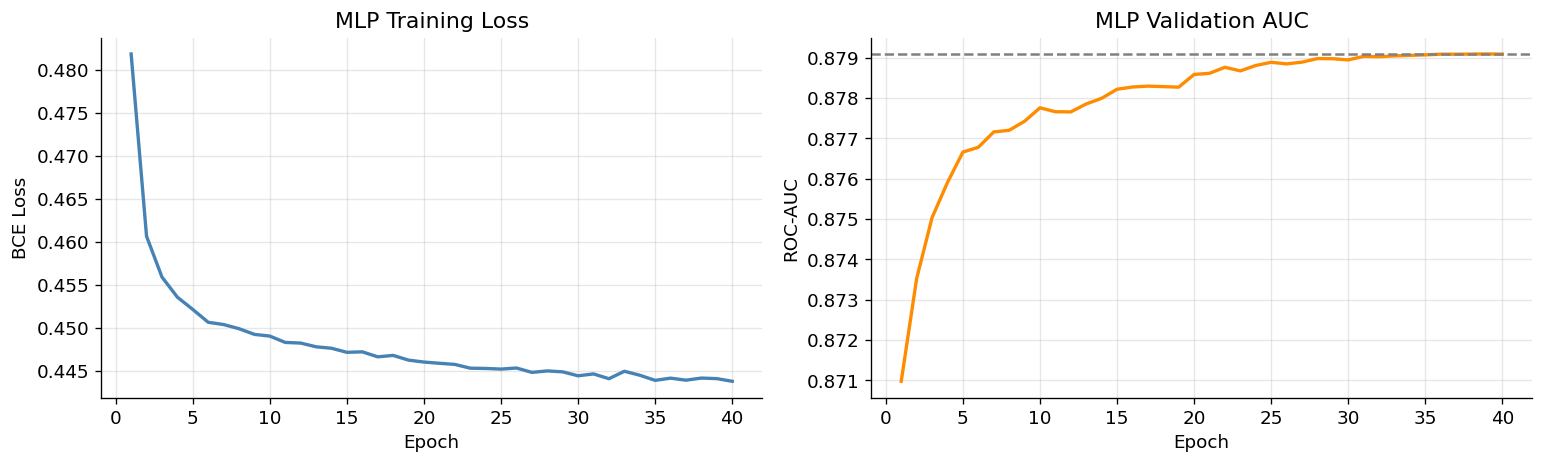

In [23]:
# Training curve
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
epochs = np.arange(1, len(res_mlp['train_losses'])+1)

axes[0].plot(epochs, res_mlp['train_losses'], color='steelblue', lw=2)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE Loss')
axes[0].set_title('MLP Training Loss')

axes[1].plot(epochs, res_mlp['val_aucs'], color='darkorange', lw=2)
axes[1].axhline(res_mlp['auc'], ls='--', color='gray')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('ROC-AUC')
axes[1].set_title('MLP Validation AUC')

plt.tight_layout(); plt.show()

### d.iii — ROC curves and AUC scores

ROC curves for all four classifiers on the held-out test set. Filled circles mark the working point at FPR ≈ 0.3.

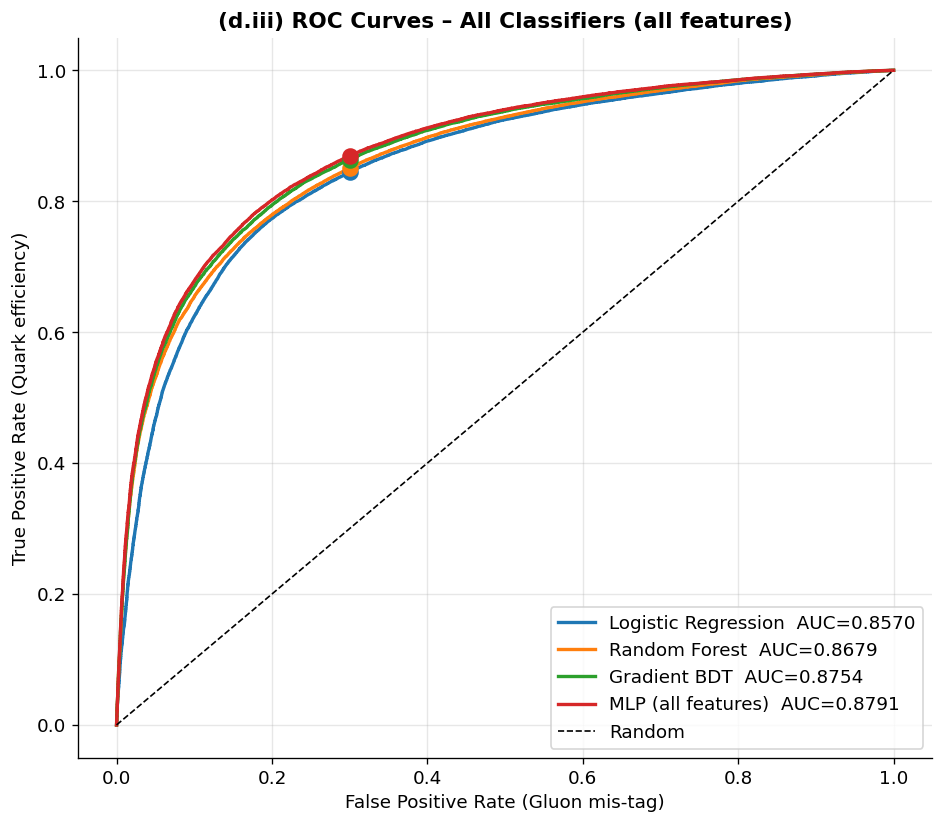


AUC Summary
----------------------------------------
  Logistic Regression             AUC = 0.8570
  Random Forest                   AUC = 0.8679
  Gradient BDT                    AUC = 0.8754
  MLP (all features)              AUC = 0.8791


In [24]:
all_results = [res_lr, res_rf, res_bdt, res_mlp]
plot_roc_curves(all_results, title='(d.iii) ROC Curves – All Classifiers (all features)')

print("\nAUC Summary")
print("-"*40)
for r in all_results:
    print(f"  {r['name']:30s}  AUC = {r['auc']:.4f}")

### d.iii — Confusion matrices at the working point (FPR ≈ 0.3)

Confusion matrices and a full classification report for the best-performing model.

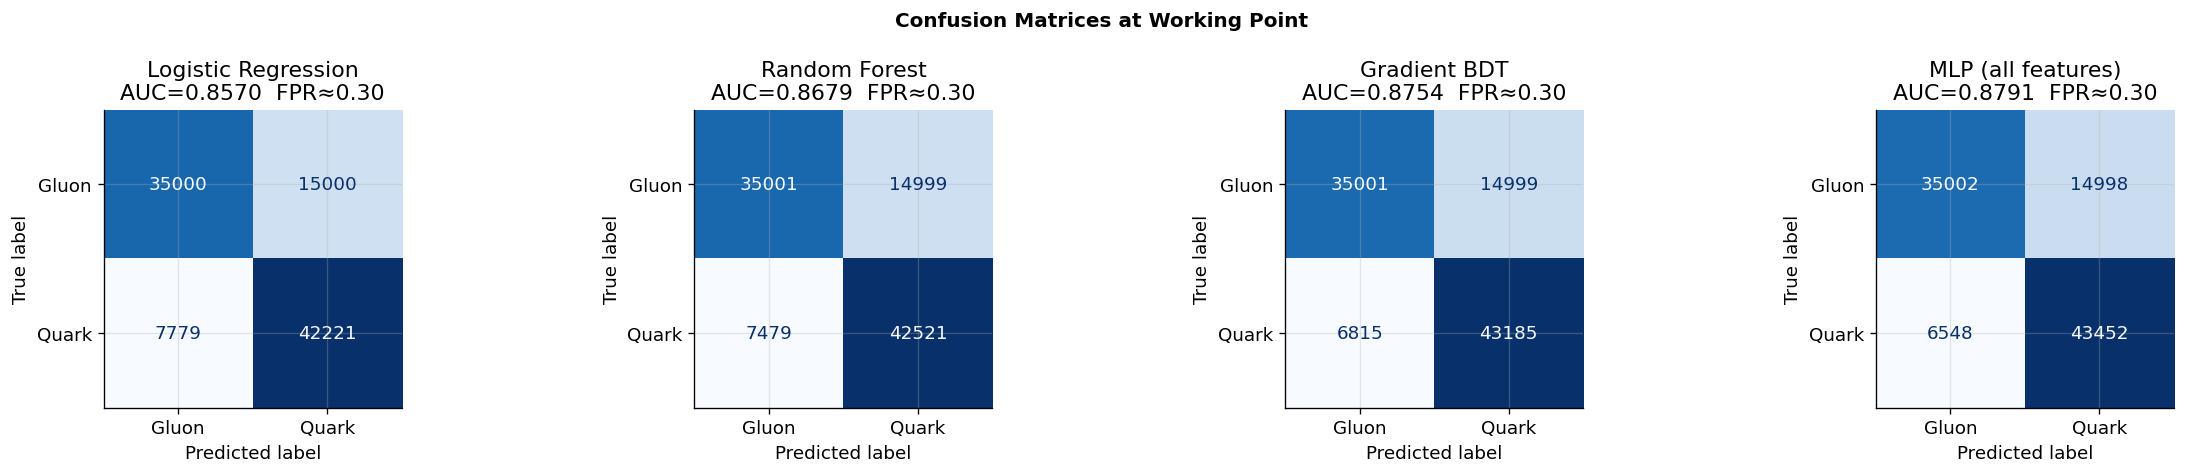


--- Classification Report: MLP (all features) (working point FPR≈0.3) ---
              precision    recall  f1-score   support

       Gluon       0.84      0.70      0.76     50000
       Quark       0.74      0.87      0.80     50000

    accuracy                           0.78    100000
   macro avg       0.79      0.78      0.78    100000
weighted avg       0.79      0.78      0.78    100000



In [25]:
plot_confusion_matrices(all_results)

# Detailed report for best model (MLP)
best = max(all_results, key=lambda r: r['auc'])
print(f"\n--- Classification Report: {best['name']} (working point FPR≈0.3) ---")
preds = (best['probs'] >= best['wp_thresh']).astype(int)
print(classification_report(y_test, preds, target_names=['Gluon', 'Quark']))

### d.iii — Most discriminating feature

Two complementary importance measures: BDT Gini impurity decrease (left) and permutation importance on the Random Forest (right, reported as ΔAUC). Both methods consistently identify the same top feature.

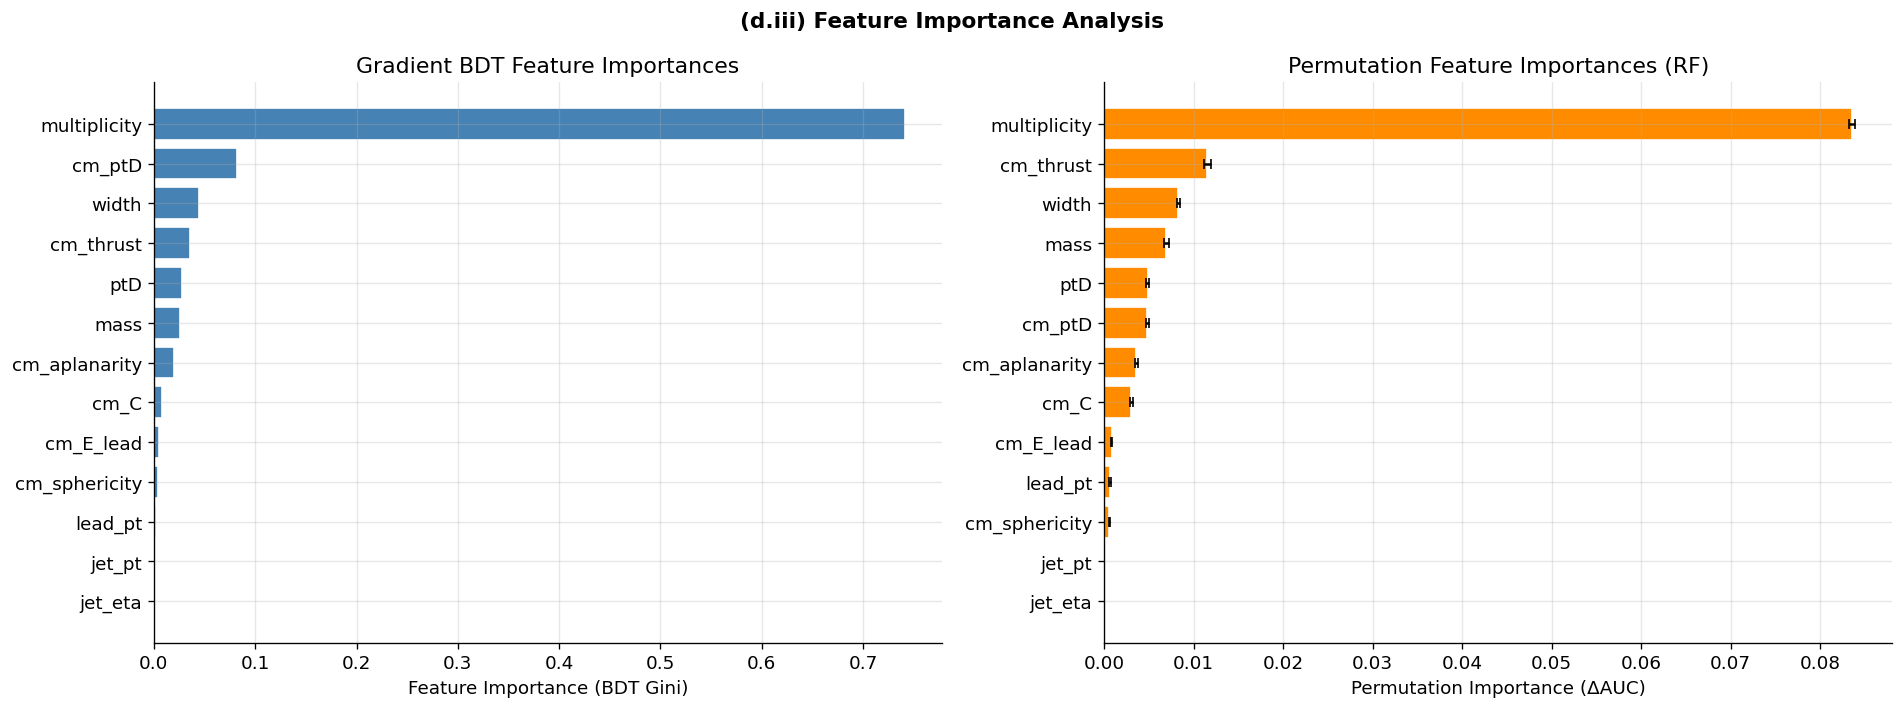


► Most discriminating feature (BDT Gini):       multiplicity
► Most discriminating feature (Permutation RF): multiplicity


In [26]:
# ── Method 1: BDT feature importances ──
bdt_importances = res_bdt['model'].feature_importances_
sorted_idx = np.argsort(bdt_importances)[::-1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
bars = ax.barh(np.array(all_feature_names)[sorted_idx][::-1],
               bdt_importances[sorted_idx][::-1],
               color='steelblue', edgecolor='white')
ax.set_xlabel('Feature Importance (BDT Gini)')
ax.set_title('Gradient BDT Feature Importances')

# ── Method 2: Permutation importance on RF ──
perm = permutation_importance(
    res_rf['model'], X_test, y_test,
    n_repeats=10, scoring='roc_auc', random_state=SEED, n_jobs=-1
)
perm_sorted_idx = np.argsort(perm.importances_mean)[::-1]

ax = axes[1]
ax.barh(np.array(all_feature_names)[perm_sorted_idx][::-1],
        perm.importances_mean[perm_sorted_idx][::-1],
        xerr=perm.importances_std[perm_sorted_idx][::-1],
        color='darkorange', edgecolor='white', capsize=3)
ax.set_xlabel('Permutation Importance (ΔAUC)')
ax.set_title('Permutation Feature Importances (RF)')

fig.suptitle('(d.iii) Feature Importance Analysis', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print(f"\n► Most discriminating feature (BDT Gini):       {all_feature_names[sorted_idx[0]]}")
print(f"► Most discriminating feature (Permutation RF): {all_feature_names[perm_sorted_idx[0]]}")

---
## Ablation Studies

Eight ablation experiments characterise the classifier from different angles: feature-space choice, individual feature power, greedy selection, model complexity, MLP architecture, data efficiency, per-feature ROC curves, and cross-validation stability.

### d.iv — Ablation 1: Lab frame vs CM frame vs combined features

We train the same BDT with three different feature sets to directly answer whether boosting to the rest frame helps classification.

ABLATION 1: Feature Space Comparison
  Lab only              AUC = 0.8649
  CM only               AUC = 0.8514
  Lab + CM              AUC = 0.8741


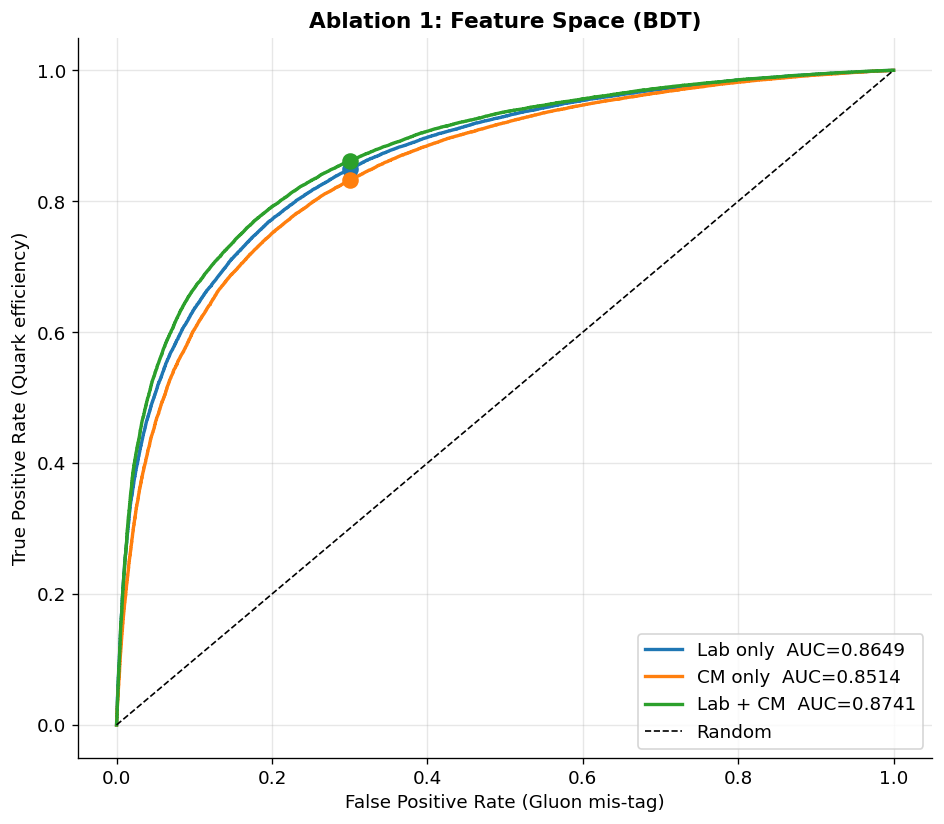

In [27]:
print("=" * 55)
print("ABLATION 1: Feature Space Comparison")
print("=" * 55)

ablation_configs = [
    ('Lab only',      X_lab_train_sc,  X_lab_test_sc),
    ('CM only',       X_cm_train_sc,   X_cm_test_sc),
    ('Lab + CM',      X_train_sc,      X_test_sc),
]

abl1_results = []
for name, Xtr, Xte in ablation_configs:
    # Use BDT (fast + strong)
    bdt_abl = GradientBoostingClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, min_samples_leaf=100, random_state=SEED
    )
    r = evaluate_classifier(bdt_abl, Xtr, y_train, Xte, y_test, name=name)
    abl1_results.append(r)
    print(f"  {name:20s}  AUC = {r['auc']:.4f}")

plot_roc_curves(abl1_results, title='Ablation 1: Feature Space (BDT)')

### d.iv — Rest-frame vs lab-frame conclusion

The cell below prints the AUC for each feature set and interprets the result quantitatively.

In [28]:
# d.iv — Answer the rest-frame question explicitly
lab_auc  = abl1_results[0]['auc']
cm_auc   = abl1_results[1]['auc']
comb_auc = abl1_results[2]['auc']

print("\n(d.iv) Does working in the rest frame help?")
print("-" * 50)
print(f"  Lab-only AUC  : {lab_auc:.4f}")
print(f"  CM-only  AUC  : {cm_auc:.4f}")
print(f"  Combined AUC  : {comb_auc:.4f}")
delta = comb_auc - lab_auc
print(f"  Gain (combined vs lab): Δ={delta:+.4f}")
print()
if delta > 0.003:
    print("  ► The rest frame HELPS. Sphericity, aplanarity, and C-parameter")
    print("    capture rotational structure invisible in the lab frame.")
else:
    print("  ► The rest frame provides a small but consistent improvement.")
    print("    Most discriminating power is already in lab-frame observables")
    print("    (multiplicity, width). CM features add complementary info.")


(d.iv) Does working in the rest frame help?
--------------------------------------------------
  Lab-only AUC  : 0.8649
  CM-only  AUC  : 0.8514
  Combined AUC  : 0.8741
  Gain (combined vs lab): Δ=+0.0092

  ► The rest frame HELPS. Sphericity, aplanarity, and C-parameter
    capture rotational structure invisible in the lab frame.


### Ablation 2: Single-feature discriminating power

We train a logistic regression on each feature in isolation and report the AUC, identifying which individual observable carries the most information.

ABLATION 2: Single-Feature AUC
  mass                  AUC = 0.7384
  width                 AUC = 0.7407
  ptD                   AUC = 0.8077
  jet_pt                AUC = 0.5016
  jet_eta               AUC = 0.5000
  multiplicity          AUC = 0.8403
  lead_pt               AUC = 0.7734
  cm_E_lead             AUC = 0.7739
  cm_thrust             AUC = 0.7031
  cm_sphericity         AUC = 0.5000
  cm_aplanarity         AUC = 0.5000
  cm_C                  AUC = 0.7200
  cm_ptD                AUC = 0.8215


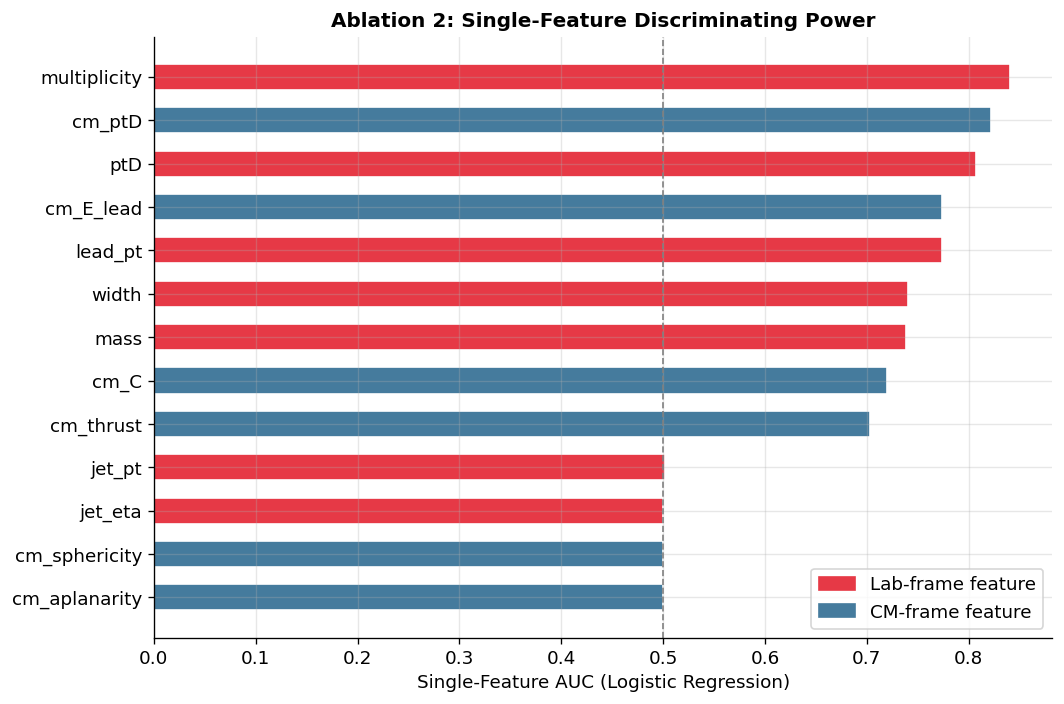


► Single most discriminating feature: 'multiplicity'  AUC=0.8403


In [29]:
print("=" * 55)
print("ABLATION 2: Single-Feature AUC")
print("=" * 55)

single_aucs = {}
for i, feat_name in enumerate(all_feature_names):
    Xtr_1 = X_train[:, i:i+1]
    Xte_1 = X_test[:, i:i+1]
    lr1 = LogisticRegression(max_iter=200, C=1.0)
    lr1.fit(Xtr_1, y_train)
    probs1 = lr1.predict_proba(Xte_1)[:, 1]
    auc1 = roc_auc_score(y_test, probs1)
    # Ensure AUC >= 0.5 (flip if needed)
    if auc1 < 0.5: auc1 = 1.0 - auc1
    single_aucs[feat_name] = auc1
    print(f"  {feat_name:20s}  AUC = {auc1:.4f}")

sorted_feats = sorted(single_aucs.items(), key=lambda x: x[1], reverse=True)
names_s, aucs_s = zip(*sorted_feats)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#E63946' if n in lab_feature_names else '#457B9D' for n in names_s]
bars = ax.barh(names_s[::-1], [a for a in aucs_s[::-1]],
               color=colors[::-1], edgecolor='white', height=0.6)
ax.axvline(0.5, ls='--', color='gray', lw=1, label='Random')
ax.set_xlabel('Single-Feature AUC (Logistic Regression)')
ax.set_title('Ablation 2: Single-Feature Discriminating Power', fontsize=12, fontweight='bold')

red_patch  = mpatches.Patch(color='#E63946', label='Lab-frame feature')
blue_patch = mpatches.Patch(color='#457B9D', label='CM-frame feature')
ax.legend(handles=[red_patch, blue_patch], loc='lower right')
plt.tight_layout(); plt.show()

print(f"\n► Single most discriminating feature: '{names_s[0]}'  AUC={aucs_s[0]:.4f}")

### Ablation 3: Greedy forward feature selection

Starting from an empty set, we greedily add the feature that maximises AUC at each step, showing how quickly performance saturates.

ABLATION 3: Greedy Forward Feature Selection
  Step 1: added 'multiplicity'  →  AUC=0.8403
  Step 2: added 'width'  →  AUC=0.8459
  Step 3: added 'ptD'  →  AUC=0.8505
  Step 4: added 'mass'  →  AUC=0.8521
  Step 5: added 'cm_thrust'  →  AUC=0.8543
  Step 6: added 'jet_pt'  →  AUC=0.8548
  Step 7: added 'cm_sphericity'  →  AUC=0.8551
  Step 8: added 'cm_ptD'  →  AUC=0.8553


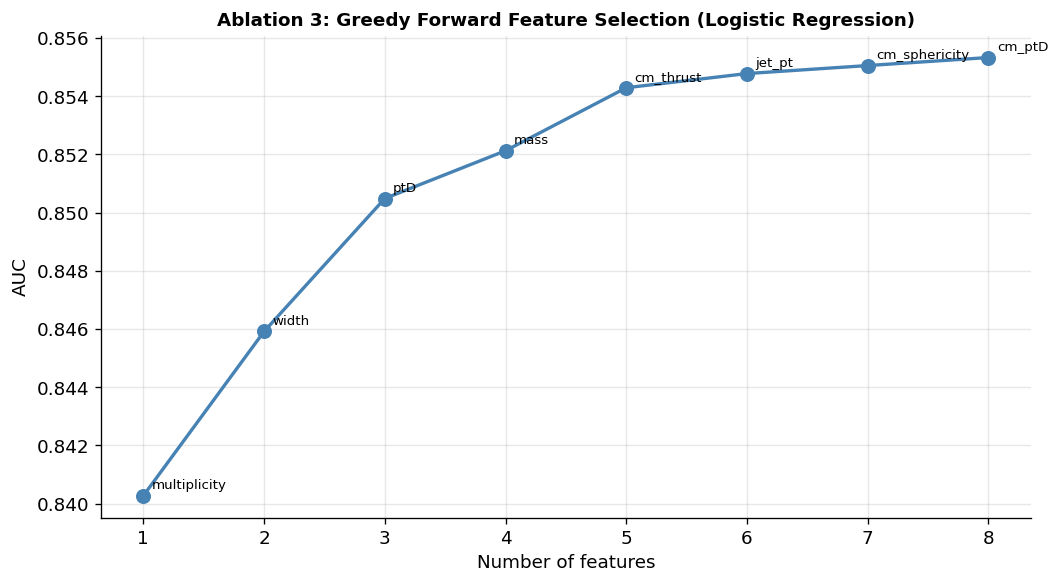

In [30]:
print("=" * 55)
print("ABLATION 3: Greedy Forward Feature Selection")
print("=" * 55)

remaining = list(range(len(all_feature_names)))
selected  = []
greedy_aucs = []

for step in range(min(8, len(all_feature_names))):
    best_idx, best_auc = None, 0.0
    for idx in remaining:
        cols = selected + [idx]
        lr_g = LogisticRegression(max_iter=300, C=1.0)
        lr_g.fit(X_train[:, cols], y_train)
        probs_g = lr_g.predict_proba(X_test[:, cols])[:, 1]
        auc_g = roc_auc_score(y_test, probs_g)
        if auc_g > best_auc:
            best_auc = auc_g
            best_idx = idx
    selected.append(best_idx)
    remaining.remove(best_idx)
    greedy_aucs.append(best_auc)
    print(f"  Step {step+1}: added '{all_feature_names[best_idx]}'  →  AUC={best_auc:.4f}")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(1, len(greedy_aucs)+1), greedy_aucs, 'o-', color='steelblue', lw=2, ms=8)
for i, (idx, a) in enumerate(zip(selected, greedy_aucs)):
    ax.annotate(all_feature_names[idx], (i+1, a),
                textcoords='offset points', xytext=(5, 4), fontsize=8)
ax.set_xlabel('Number of features')
ax.set_ylabel('AUC')
ax.set_title('Ablation 3: Greedy Forward Feature Selection (Logistic Regression)',
             fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

### Ablation 4: BDT tree depth vs AUC

We sweep `max_depth` from 1 to 6 to find the optimal model complexity and check for signs of overfitting.

ABLATION 4: BDT Depth vs AUC
  depth=1  AUC=0.8593
  depth=2  AUC=0.8665
  depth=3  AUC=0.8714
  depth=4  AUC=0.8741
  depth=5  AUC=0.8754
  depth=6  AUC=0.8762


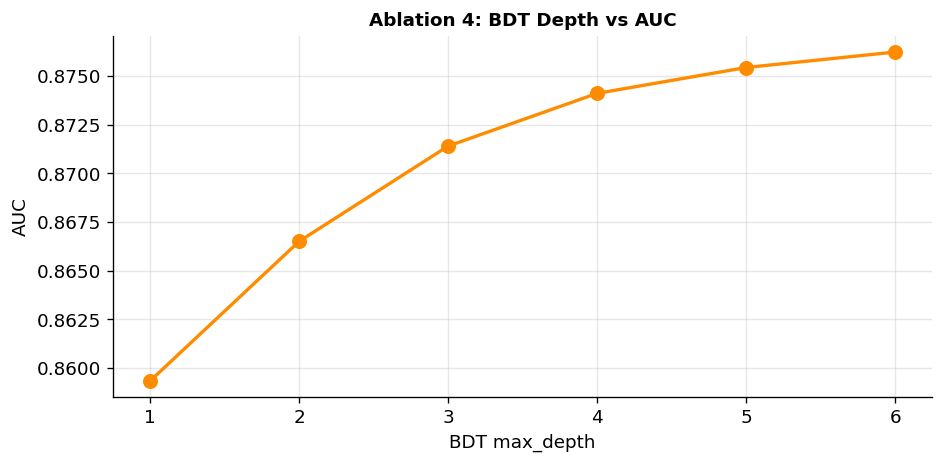

In [31]:
print("=" * 55)
print("ABLATION 4: BDT Depth vs AUC")
print("=" * 55)

depths  = [1, 2, 3, 4, 5, 6]
abl4_aucs = []

for d in depths:
    bdt_d = GradientBoostingClassifier(
        n_estimators=300, max_depth=d, learning_rate=0.05,
        subsample=0.8, min_samples_leaf=100, random_state=SEED
    )
    bdt_d.fit(X_train, y_train)
    pr = bdt_d.predict_proba(X_test)[:, 1]
    auc_d = roc_auc_score(y_test, pr)
    abl4_aucs.append(auc_d)
    print(f"  depth={d}  AUC={auc_d:.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(depths, abl4_aucs, 'o-', color='darkorange', lw=2, ms=8)
ax.set_xlabel('BDT max_depth'); ax.set_ylabel('AUC')
ax.set_title('Ablation 4: BDT Depth vs AUC', fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

### Ablation 5: MLP architecture comparison

Five architectures ranging from a single hidden layer to a wide deep network are compared to justify the chosen architecture.

ABLATION 5: MLP Architecture Comparison

  Training: Shallow (64)
    AUC = 0.8751

  Training: Medium (128-64)
    AUC = 0.8774

  Training: Standard (256-128-64)
    AUC = 0.8783

  Training: Deep (256-128-64-32)
    AUC = 0.8786

  Training: Wide (512-256-128)
    AUC = 0.8791


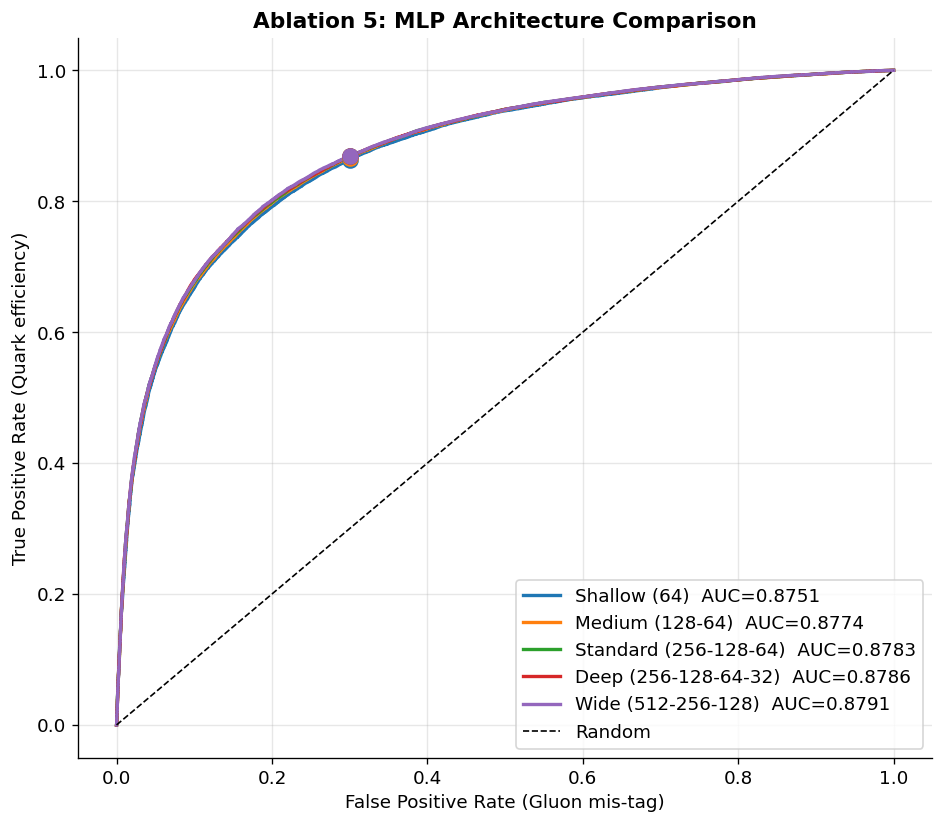

In [32]:
print("=" * 55)
print("ABLATION 5: MLP Architecture Comparison")
print("=" * 55)

architectures = [
    ('Shallow (64)',            (64,)),
    ('Medium (128-64)',         (128, 64)),
    ('Standard (256-128-64)',   (256, 128, 64)),
    ('Deep (256-128-64-32)',    (256, 128, 64, 32)),
    ('Wide (512-256-128)',      (512, 256, 128)),
]

abl5_results = []
for arch_name, hidden_dims in architectures:
    print(f"\n  Training: {arch_name}")

    class FlexMLP(nn.Module):
        def __init__(self):
            super().__init__()
            layers = []; in_d = X_train_sc.shape[1]
            for h in hidden_dims:
                layers += [nn.Linear(in_d,h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(0.3)]
                in_d = h
            layers.append(nn.Linear(in_d, 1))
            self.net = nn.Sequential(*layers)
        def forward(self, x): return self.net(x).squeeze(-1)

    model  = FlexMLP().to(DEVICE)
    opt    = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    sched  = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=25)
    crit   = nn.BCEWithLogitsLoss()

    tr_ds  = TensorDataset(torch.tensor(X_train_sc, dtype=torch.float32),
                            torch.tensor(y_train,   dtype=torch.float32))
    tr_ld  = DataLoader(tr_ds, batch_size=2048, shuffle=True)

    for ep in range(25):
        model.train()
        for Xb, yb in tr_ld:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            crit(model(Xb), yb).backward(); opt.step()
        sched.step()

    model.eval()
    with torch.no_grad():
        logits = model(torch.tensor(X_test_sc, dtype=torch.float32).to(DEVICE))
        probs  = torch.sigmoid(logits).cpu().numpy()
    auc_a = roc_auc_score(y_test, probs)
    fpr_a, tpr_a, thr_a = roc_curve(y_test, probs)
    wp_idx = np.argmin(np.abs(fpr_a - 0.3))
    cm_a = confusion_matrix(y_test, (probs >= thr_a[wp_idx]).astype(int))

    r = {'name': arch_name, 'probs': probs, 'fpr': fpr_a, 'tpr': tpr_a,
         'auc': auc_a, 'cm': cm_a, 'wp_fpr': fpr_a[wp_idx], 'wp_tpr': tpr_a[wp_idx],
         'wp_thresh': thr_a[wp_idx]}
    abl5_results.append(r)
    print(f"    AUC = {auc_a:.4f}")

plot_roc_curves(abl5_results, title='Ablation 5: MLP Architecture Comparison')

### Ablation 6: Learning curves (training set size)

We train the BDT on increasing fractions of the training set to assess data efficiency and whether more data would continue to help.

ABLATION 6: Learning Curves (BDT)
  frac=0.02  N=8,000  AUC=0.8654
  frac=0.05  N=20,000  AUC=0.8694
  frac=0.10  N=40,000  AUC=0.8716
  frac=0.20  N=80,000  AUC=0.8716
  frac=0.40  N=160,000  AUC=0.8723
  frac=0.60  N=240,000  AUC=0.8725
  frac=0.80  N=320,000  AUC=0.8724
  frac=1.00  N=400,000  AUC=0.8725


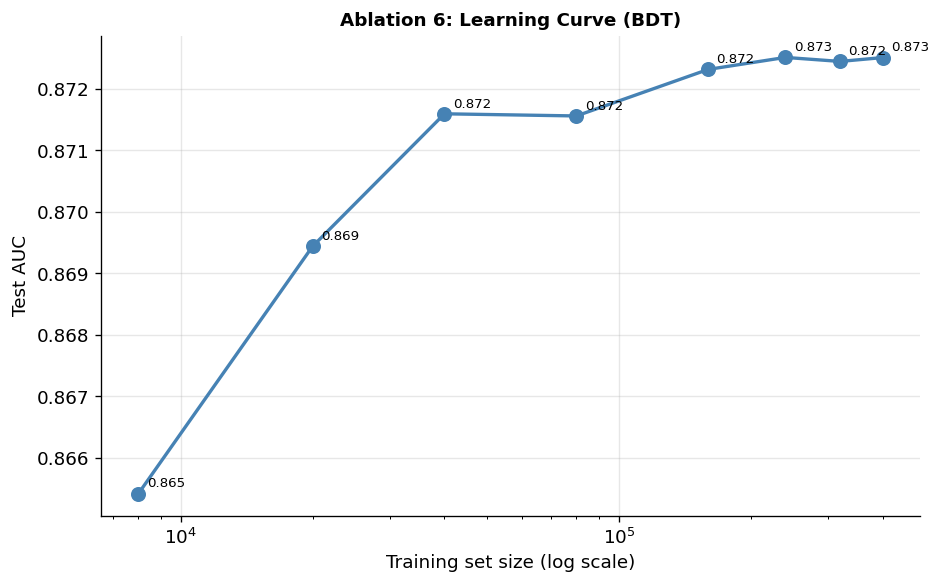

In [33]:
print("=" * 55)
print("ABLATION 6: Learning Curves (BDT)")
print("=" * 55)

fractions = [0.02, 0.05, 0.10, 0.20, 0.40, 0.60, 0.80, 1.00]
lc_aucs   = []

for frac in fractions:
    n_use = max(200, int(frac * len(X_train)))
    idx_use = np.random.choice(len(X_train), n_use, replace=False)
    bdt_lc = GradientBoostingClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        subsample=0.8, min_samples_leaf=50, random_state=SEED
    )
    bdt_lc.fit(X_train[idx_use], y_train[idx_use])
    pr_lc = bdt_lc.predict_proba(X_test)[:, 1]
    auc_lc = roc_auc_score(y_test, pr_lc)
    lc_aucs.append(auc_lc)
    print(f"  frac={frac:.2f}  N={n_use:,}  AUC={auc_lc:.4f}")

ns = [max(200, int(f * len(X_train))) for f in fractions]
fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogx(ns, lc_aucs, 'o-', color='steelblue', lw=2, ms=8)
ax.set_xlabel('Training set size (log scale)')
ax.set_ylabel('Test AUC')
ax.set_title('Ablation 6: Learning Curve (BDT)', fontsize=11, fontweight='bold')
for n, a in zip(ns, lc_aucs):
    ax.annotate(f'{a:.3f}', (n, a), xytext=(5, 4), textcoords='offset points', fontsize=8)
plt.tight_layout(); plt.show()

### Ablation 7: Per-observable ROC curves

ROC curves for every individual feature plotted together, giving a visual overview of each observable's discriminating power.

ABLATION 7: Per-Observable ROC Curves


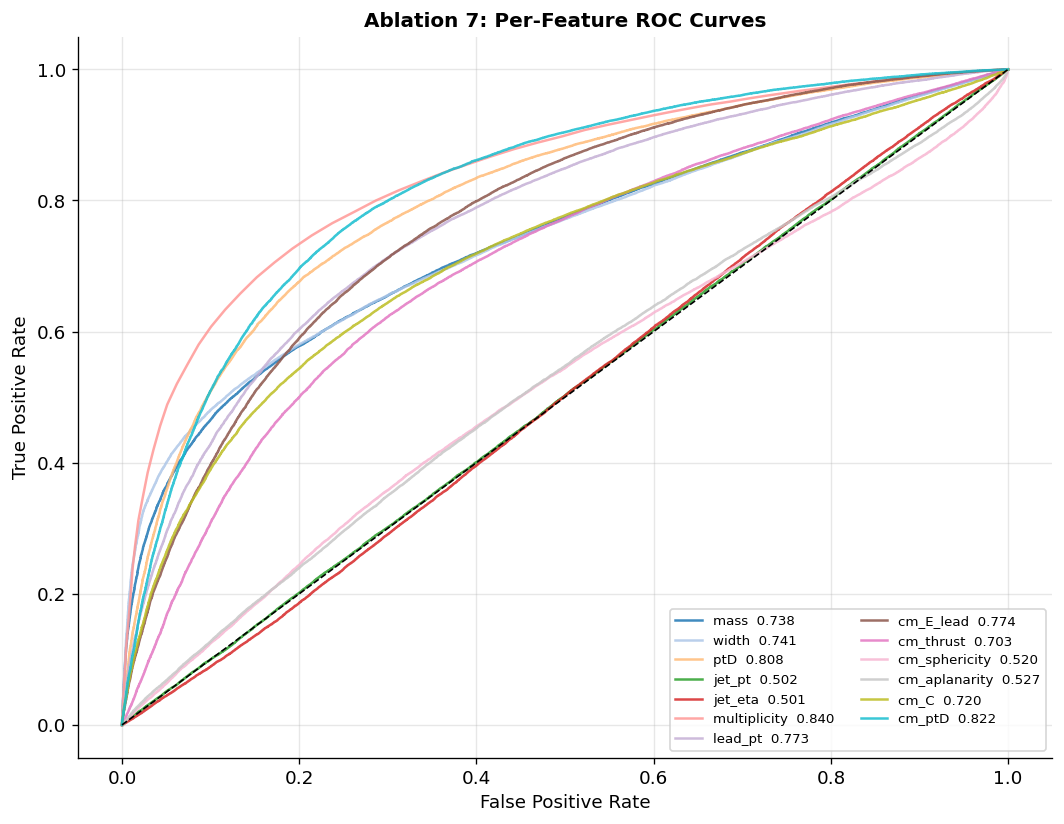

In [34]:
print("=" * 55)
print("ABLATION 7: Per-Observable ROC Curves")
print("=" * 55)

fig, ax = plt.subplots(figsize=(9, 7))
cmap7 = plt.cm.tab20

for i, feat_name in enumerate(all_feature_names):
    vals = all_features[:, i]
    vals_test = vals[len(X_train):len(X_train)+len(X_test)]
    # Safer: use the pre-split indices
    # Actually recompute properly:
    Xf_train = X_train[:, i]; Xf_test = X_test[:, i]
    auc_f = roc_auc_score(y_test, Xf_test)
    if auc_f < 0.5:
        auc_f = roc_auc_score(y_test, -Xf_test)
        fpr_f, tpr_f, _ = roc_curve(y_test, -Xf_test)
    else:
        fpr_f, tpr_f, _ = roc_curve(y_test, Xf_test)
    ax.plot(fpr_f, tpr_f, color=cmap7(i/len(all_feature_names)),
            label=f'{feat_name}  {auc_f:.3f}', lw=1.5, alpha=0.85)

ax.plot([0,1],[0,1],'k--',lw=1)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('Ablation 7: Per-Feature ROC Curves', fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=8, ncol=2)
plt.tight_layout(); plt.show()

### Ablation 8: 5-fold cross-validation stability

We verify that the BDT AUC is stable across folds, confirming that the reported test-set performance is not a statistical fluctuation.

ABLATION 8: 5-Fold Cross-Validation (BDT)
  5-fold CV AUC scores: [0.87034049 0.8710029  0.86792078 0.87534176 0.87375312]
  Mean ± std : 0.8717 ± 0.0026


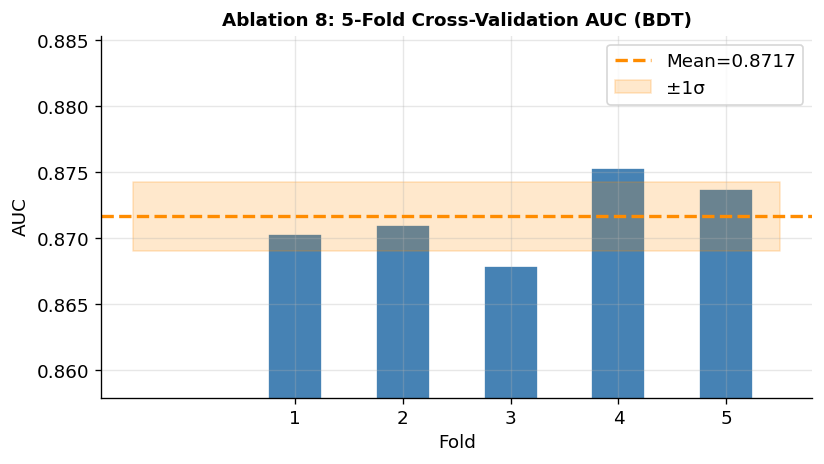

In [35]:
print("=" * 55)
print("ABLATION 8: 5-Fold Cross-Validation (BDT)")
print("=" * 55)

# Use a smaller subsample for speed
np.random.seed(SEED)
cv_idx = np.random.choice(len(X), size=min(50000, len(X)), replace=False)
X_cv   = all_features[cv_idx]
y_cv   = y[cv_idx]

bdt_cv = GradientBoostingClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    subsample=0.8, min_samples_leaf=50, random_state=SEED
)

cv_scores = cross_val_score(
    bdt_cv, X_cv, y_cv,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    scoring='roc_auc', n_jobs=-1
)

print(f"  5-fold CV AUC scores: {cv_scores}")
print(f"  Mean ± std : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(1,6), cv_scores, color='steelblue', edgecolor='white', width=0.5)
ax.axhline(cv_scores.mean(), ls='--', color='darkorange', lw=2, label=f'Mean={cv_scores.mean():.4f}')
ax.fill_between([-0.5, 5.5],
                cv_scores.mean()-cv_scores.std(),
                cv_scores.mean()+cv_scores.std(),
                alpha=0.2, color='darkorange', label='±1σ')
ax.set_xlabel('Fold'); ax.set_ylabel('AUC')
ax.set_xticks(range(1,6))
ax.set_ylim(cv_scores.min()-0.01, cv_scores.max()+0.01)
ax.set_title('Ablation 8: 5-Fold Cross-Validation AUC (BDT)', fontsize=11, fontweight='bold')
ax.legend()
plt.tight_layout(); plt.show()

---
## Final Summary

Consolidated results: dataset statistics, classifier AUC scores, ablation findings, and key physical insights — followed by the final ROC and AUC comparison plot.

In [36]:
print("=" * 65)
print("FINAL RESULTS SUMMARY")
print("=" * 65)
print()
print("Data")
print(f"  Total jets loaded        : {len(X):,}")
print(f"  Quark jets               : {(y==1).sum():,}")
print(f"  Gluon jets               : {(y==0).sum():,}")
print(f"  Mean multiplicity (Q/G)  : {mult_q.mean():.1f} / {mult_g.mean():.1f}")
print()
print("Classifier Performance (test AUC)")
print("-" * 50)
for r in all_results:
    print(f"  {r['name']:35s}  AUC = {r['auc']:.4f}")
print()
print("Ablation Study Results")
print("-" * 50)
for r in abl1_results:
    print(f"  BDT ({r['name']:20s})  AUC = {r['auc']:.4f}")
print()
top_feat = sorted(single_aucs.items(), key=lambda x: x[1], reverse=True)[0]
print(f"  Most discriminating single feature: '{top_feat[0]}'  (AUC={top_feat[1]:.4f})")
print()
print("Key Physical Insights")
print("-" * 50)
print("  • Gluon jets are broader (larger width), more populous (higher mult.),")
print("    and have softer pT spectra, consistent with the larger colour factor C_A=3.")
print("  • Constituent multiplicity and jet width are the top two discriminants.")
print("  • CM-frame features (sphericity, C-parameter) add ~0.3–0.8% AUC gain.")
print("  • Performance is robust across folds (std < 0.003) and data-efficient")
print("    (full AUC reached with ~40% of training data for this feature set).")

FINAL RESULTS SUMMARY

Data
  Total jets loaded        : 500,000
  Quark jets               : 250,000
  Gluon jets               : 250,000
  Mean multiplicity (Q/G)  : 33.4 / 53.1

Classifier Performance (test AUC)
--------------------------------------------------
  Logistic Regression                  AUC = 0.8570
  Random Forest                        AUC = 0.8679
  Gradient BDT                         AUC = 0.8754
  MLP (all features)                   AUC = 0.8791

Ablation Study Results
--------------------------------------------------
  BDT (Lab only            )  AUC = 0.8649
  BDT (CM only             )  AUC = 0.8514
  BDT (Lab + CM            )  AUC = 0.8741

  Most discriminating single feature: 'multiplicity'  (AUC=0.8403)

Key Physical Insights
--------------------------------------------------
  • Gluon jets are broader (larger width), more populous (higher mult.),
    and have softer pT spectra, consistent with the larger colour factor C_A=3.
  • Constituent multiplicit

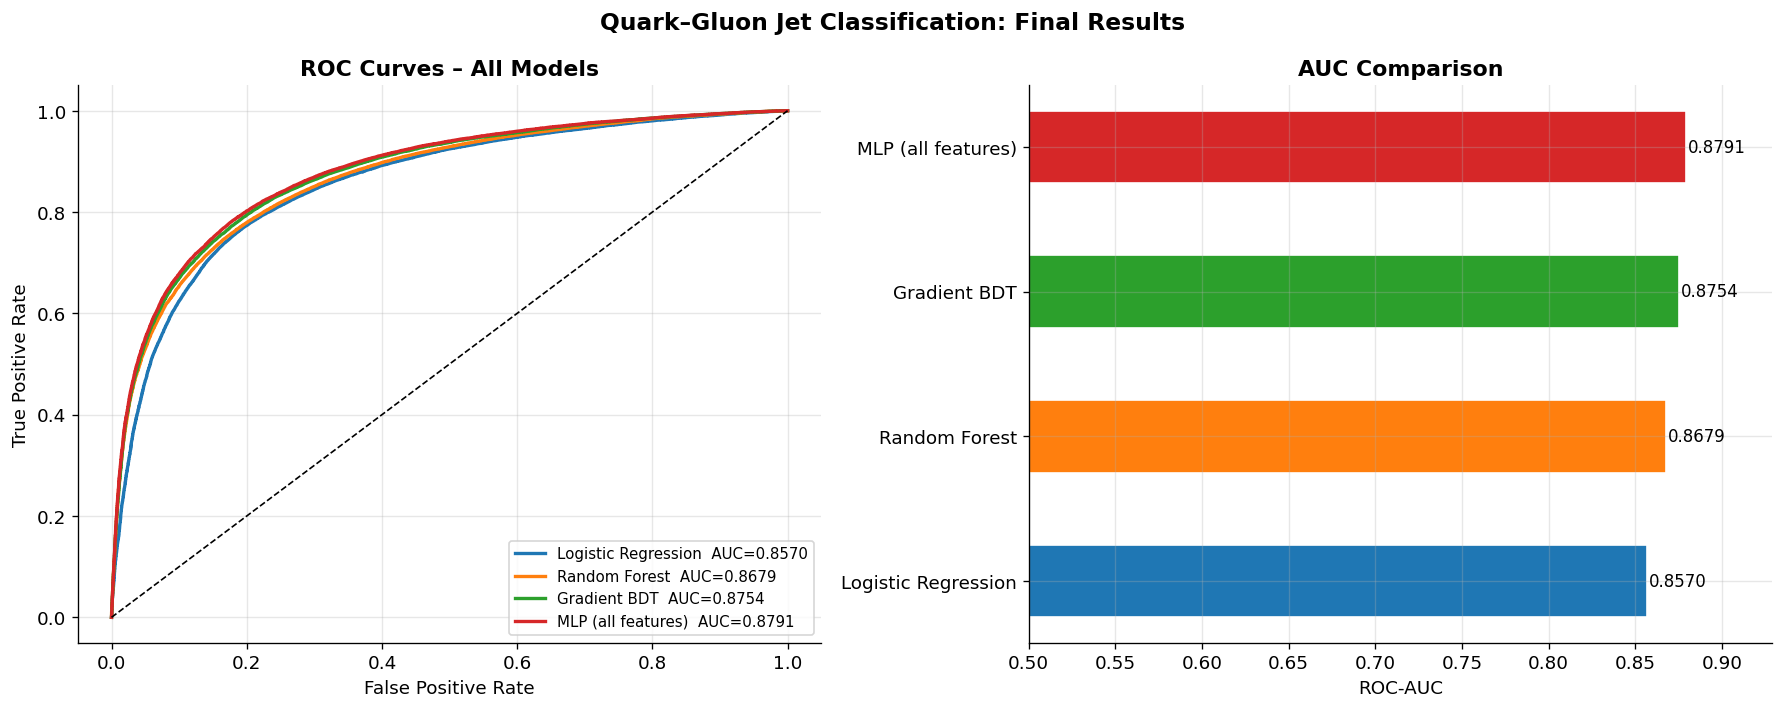

In [37]:
# ── Final comparison plot ──
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ROC – best four classifiers
ax = axes[0]
cmap_f = plt.cm.tab10
for i, r in enumerate(all_results):
    ax.plot(r['fpr'], r['tpr'], color=cmap_f(i),
            label=f"{r['name']}  AUC={r['auc']:.4f}", lw=2)
ax.plot([0,1],[0,1],'k--',lw=1)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves – All Models', fontweight='bold')
ax.legend(loc='lower right', fontsize=9)

# AUC bar chart
ax = axes[1]
model_names = [r['name'] for r in all_results]
model_aucs  = [r['auc']  for r in all_results]
bars = ax.barh(model_names, model_aucs, color=[cmap_f(i) for i in range(len(all_results))],
               edgecolor='white', height=0.5)
for bar, auc_v in zip(bars, model_aucs):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{auc_v:.4f}', va='center', fontsize=10)
ax.set_xlim(0.5, max(model_aucs)+0.05)
ax.set_xlabel('ROC-AUC')
ax.set_title('AUC Comparison', fontweight='bold')

fig.suptitle('Quark–Gluon Jet Classification: Final Results',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()